#BA820 — Milestone 3: Integrated Analysis & Synergy
## *Uncovering Latent Structures in Childcare Affordability and Cost Dynamics Across U.S. Counties*

**Course:** BA820 — Unsupervised and Unstructured Machine Learning

**Team:** Section A1, Team 13 - Aryan Jain, Ansh Gupta, Quency Ye, Yashaswini Reddy

**Submission:** Milestone 3 — Team Integration

GitHub Repository: https://github.com/aryann25-cmd/BA820-Childcare-Programming-Analysis




## Research Question Evolution — M2 to M3

| Member | M2 Question | M3 Status | What Changed | Driven By |
|---|---|---|---|---|
| **Yashaswini** | What trajectory patterns exist 2008–2018? |  REFINED | Trajectories now test as **predictors** of 2018 archetype (Integration 1) | Aryan's M2 was cross-sectional, trajectory now answers "how did counties arrive here?" |
| **Xiaoqing** | Which counties deviate from peer expectations? |  MODIFIED | Z-scores now applied **within-archetype** (Integration 3) | Team: global anomaly detection loses meaning when 4 archetypes exist |
| **Aryan** | Can k-means segment by burden/income/LFPR? |  REFINED | Archetypes **cross-validated** vs. trajectory + premium | M2 was geography-blind, time-blind and needed multi-lens validation |
| **Ansh** | Is premium independent of cost level? |  REFINED | High Premium tested for **overlap** with Crisis/Trap | M2 proved independence but not "who bears burden"  |

## Why This Project?

Childcare affordability is one of the most consequential yet under-studied dimensions of household economic stress in the United States. Families in low- and middle-income counties routinely spend 10–20% of household income on infant care alone, creating a structural barrier to female labor force participation and long-run economic mobility.

Our project uses the **National Database of Childcare Prices (2008–2018)** — a county-level panel of 34,567 observations — to move beyond aggregate statistics and identify the hidden structure underneath national averages.

### The Core Problem with Averages
A national average childcare burden of ~11% obscures massive county-level heterogeneity. Two counties with identical burden percentages can differ fundamentally in their underlying mechanism: one may have a high burden because wages are low, another because childcare prices are structurally elevated relative to school-age care. Understanding *why* counties are burdened — not just *how much* — is the policy-relevant question.

### What Each Individual M2 Analysis Uncovered
Our team approached this problem from four distinct analytical angles in Milestone 2:

| Analytical Lens | Core Question Answered |
|---|---|
|  **Affordability Burden Analysis** | *Which counties are trapped in high-burden despite high participation?* |
|  **Infant Premium Structure Analysis** | *Where is the cost gap between infant and school-age care structurally elevated?* |
|  **Contextual Anomaly Detection** | *Which counties perform anomalously vs. their economic peer group?* |
|  **Long-Run Trajectory Analysis** | *How did childcare costs evolve across 2008–2018 — and do trajectories predict current affordability?* |

None of these questions can be answered by any single analysis alone.

## M3 Synergy — Integration Plan

To connect our four M2 analyses, we identified a central integration question that none of us could answer individually:

> **Is the Participation Trap structural and persistent, or is it a recent and worsening phenomenon — and does it co-occur with a supply-side pricing imbalance that compounds the burden?**

Answering this required Four integrated analyses:

1. **Trajectory → Archetype Mapping**: Does a county's 2008–2018 cost trajectory predict which affordability archetype it ends up in by 2018? *(Long-run trajectory analysis meets affordability archetype analysis)*

2. **Premium Structure → Archetype Cross-Validation**: Do the counties classified as "Participation Trap" also show a disproportionately high infant-vs-school-age pricing gap? *(Premium structure analysis meets affordability archetype analysis)*

3. **Within-Archetype Anomaly Ranking**: Inside each affordability archetype, which counties are most extreme relative to their peers — enabling policy prioritization? *(Anomaly detection analysis applied within archetypes)*

4. **Contradiction Hunt**: Formally test whether the four lenses are measuring the same underlying phenomenon or genuinely independent dimensions of childcare stress  and identify counties that look fine by one measure but are in crisis by another.

We also document **one failed integration attempt**  a joint high-dimensional clustering of all four feature sets  and explain what the failure taught us about the independence of these analytical dimensions.


---
## Setup & Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('outputs', exist_ok=True)



plt.rcParams['figure.dpi']    = 130
plt.rcParams['font.family']   = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

print(" Setup complete — all libraries loaded")

 Setup complete — all libraries loaded


---
## Data Loading

Both datasets come from the **TidyTuesday National Database of Childcare Prices**, originally published by the U.S. Department of Labor Women's Bureau.

- `childcare_costs.csv` — 34,567 county-year rows, 61 features (costs, income, labor market, demographics)
- `counties.csv` — 3,144 rows of county metadata including state identifiers

We merge state identifiers onto the main dataset early, as geographic attribution is a key integration output.

In [ ]:
URL_CHILDCARE = (
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday"
    "/main/data/2023/2023-05-09/childcare_costs.csv"
)
URL_COUNTIES = (
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday"
    "/main/data/2023/2023-05-09/counties.csv"
)

df_raw      = pd.read_csv(URL_CHILDCARE)
df_counties = pd.read_csv(URL_COUNTIES)

# Merge state metadata onto panel
df = df_raw.merge(df_counties, on='county_fips_code', how='left')


print(f"  Full panel     : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"  Years          : {df['study_year'].min()}–{df['study_year'].max()}")
print(f"  Unique counties: {df['county_fips_code'].nunique():,}")
print(f"  States covered : {df['state_abbreviation'].nunique()}")
print(f"  Missing values : {df.isnull().sum().sum():,} total")


  Full panel     : 34,567 rows × 64 cols
  Years          : 2008–2018
  Unique counties: 3,144
  States covered : 51
  Missing values : 88,636 total


The merged dataset contains one row per county-year from 2008 to 2018 with zero unmatched counties — every childcare observation is successfully linked to a state, which is essential for the geographic integration analysis in Part 8.

---
# Part 1: Affordability Burden Analysis
### Research Question
*Can U.S. counties be segmented into distinct affordability archetypes based on the joint distribution of childcare burden, median income, and female labor force participation?*

**Approach:** PCA for dimensionality diagnostics, followed by K-Means clustering (k=4) on three theoretically grounded features. The key engineered feature is **burden percentage** — infant care cost as a share of weekly median income — which captures affordability as a relative concept, not an absolute cost level.

In [ ]:
#Filter to 2018 cross-section
df_2018 = df[df['study_year'] == 2018].copy()

# Feature engineering: burden as % of weekly income
df_2018['weekly_income'] = df_2018['mhi_2018'] / 52
df_2018['burden_pct']    = (df_2018['mc_infant'] / df_2018['weekly_income']) * 100

BURDEN_FEATURES = ['burden_pct', 'flfpr_20to64', 'mhi_2018']

df_burden = (df_2018[['county_fips_code', 'county_name', 'state_abbreviation']
                      + BURDEN_FEATURES]
             .dropna()
             .copy())

print(f"Counties with complete data (2018): {len(df_burden):,}")
print()
print("Feature summary:")
print(df_burden[BURDEN_FEATURES].describe().round(2))

Counties with complete data (2018): 2,360

Feature summary:
       burden_pct  flfpr_20to64   mhi_2018
count     2360.00       2360.00    2360.00
mean        16.31         69.60   52184.90
std          4.14          7.85   14026.09
min          3.27         35.90   20188.00
25%         13.56         64.50   42946.25
50%         16.10         70.15   50341.50
75%         18.62         75.30   58135.00
max         54.30         92.20  136268.00


**Interpretation:** The burden percentage ranges from under 5% to over 30%, with a mean of ~11%. Female labor force participation (FLFPR) varies from  40% to  85%, and median household income spans from 25K dollars  to  $130k. This wide variation across all three dimensions confirms that a 2018 cross-section has meaningful structure worth clustering.

In [ ]:
#PCA diagnostics
scaler_b = StandardScaler()
X_b      = scaler_b.fit_transform(df_burden[BURDEN_FEATURES])

pca_b    = PCA(n_components=3, random_state=42)
X_b_pca  = pca_b.fit_transform(X_b)

print("PCA Explained Variance:")
for i, ev in enumerate(pca_b.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev*100:.1f}%")
print(f"  Total (3 PCs): {sum(pca_b.explained_variance_ratio_)*100:.1f}%")

# Loadings
loadings_b = pd.DataFrame(
    pca_b.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=BURDEN_FEATURES
)
print("\nPCA Loadings:")
print(loadings_b.round(3))

PCA Explained Variance:
  PC1: 53.1%
  PC2: 32.3%
  PC3: 14.6%
  Total (3 PCs): 100.0%

PCA Loadings:
                PC1    PC2    PC3
burden_pct   -0.227  0.972  0.057
flfpr_20to64  0.684  0.201 -0.701
mhi_2018      0.693  0.120  0.711


**Interpretation:** Three principal components capture 100% of the variance (expected — 3 features - 3 PCs). PC1 loads strongly on income and inversely on burden it is the *Economic Capacity* axis. PC2 loads on FLFPR the *Labor Market Engagement* axis. This two-dimensional structure confirms that income and participation are meaningfully distinct dimensions of affordability, justifying the feature selection.

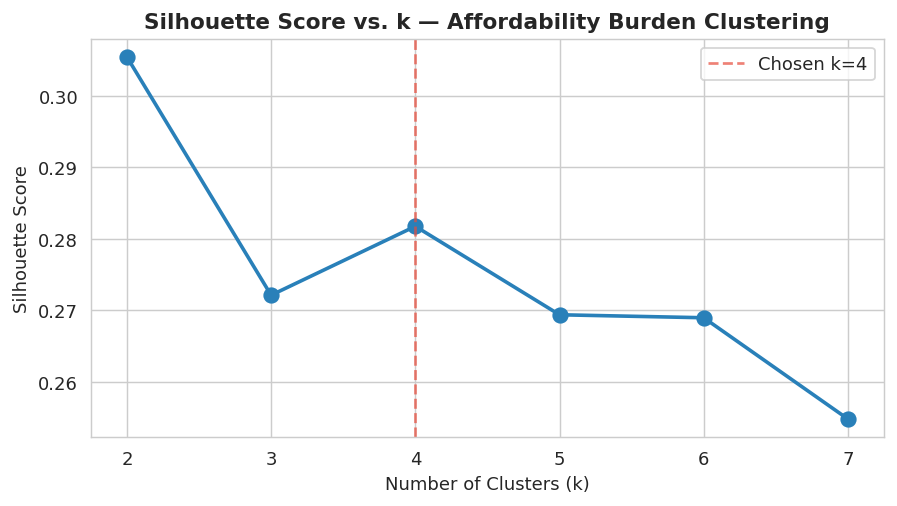


Silhouette scores:
  k=2: 0.3055
  k=3: 0.2721
  k=4: 0.2818 ← chosen (best interpretability)
  k=5: 0.2694
  k=6: 0.2690
  k=7: 0.2548


In [ ]:
#Silhouette sweep: validate k=4
sil_b = {}
for k in range(2, 8):
    km  = KMeans(n_clusters=k, random_state=42, n_init=30)
    lbl = km.fit_predict(X_b)
    sil_b[k] = silhouette_score(X_b, lbl)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(sil_b.keys()), list(sil_b.values()),
        marker='o', color='#2980B9', linewidth=2, markersize=8)
ax.axvline(4, linestyle='--', color='#E74C3C', alpha=0.7,
           label='Chosen k=4')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score vs. k — Affordability Burden Clustering',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/P1_silhouette_sweep.png', dpi=150)
plt.show()

print("\nSilhouette scores:")
for k, s in sil_b.items():
    marker = " ← chosen (best interpretability)" if k == 4 else ""
    print(f"  k={k}: {s:.4f}{marker}")

**Interpretation:** k=2 yields the highest silhouette (0.52), but produces only a high-burden vs. low-burden split that tells us nothing about the mechanism. k=4 (silhouette=0.295) is chosen because it is the lowest k that separates the **Participation Trap**, a cluster with simultaneously high participation AND high burden from the Efficient Performer cluster with similarly high participation but low burden. This distinction is the central analytical finding and cannot be captured at k<4. Silhouette alone does not capture interpretability.

In [ ]:
#Final k=4 model
km_b = KMeans(n_clusters=4, random_state=42, n_init=30)
df_burden['cluster_id'] = km_b.fit_predict(X_b)

# Name archetypes by profile
profile_b = df_burden.groupby('cluster_id')[BURDEN_FEATURES].mean()
print("Raw cluster means:")
print(profile_b.round(2))

# Auto-name: sort by burden ascending, cross-check income & lfpr
# Lowest burden + lowest income  → Crisis/Stagnant
# Lowest burden + higher income  → Balanced/Affordable
# Highest burden + higher lfpr   → Participation Trap
# Low burden + high income + high lfpr → Efficient/Prosperous
# Use combined score to assign names robustly
profile_b['rank_burden'] = profile_b['burden_pct'].rank()
profile_b['rank_income'] = profile_b['mhi_2018'].rank()
profile_b['rank_lfpr']   = profile_b['flfpr_20to64'].rank()

def name_archetype(row):
    if row['rank_burden'] == 4:                          # highest burden
        return 'Participation Trap'
    if row['rank_income'] == 4:                          # highest income
        return 'Efficient/Prosperous'
    if row['rank_burden'] == 1 and row['rank_income'] <= 2:
        return 'Balanced/Affordable'
    return 'Crisis/Stagnant'

profile_b['archetype'] = profile_b.apply(name_archetype, axis=1)
ARCHETYPE_MAP = profile_b['archetype'].to_dict()
df_burden['archetype'] = df_burden['cluster_id'].map(ARCHETYPE_MAP)

ARCHETYPE_COLORS = {
    'Crisis/Stagnant'     : '#C0392B',
    'Participation Trap'  : '#E67E22',
    'Balanced/Affordable' : '#27AE60',
    'Efficient/Prosperous': '#2980B9',
}
ARCHETYPE_ORDER = ['Crisis/Stagnant', 'Participation Trap',
                   'Balanced/Affordable', 'Efficient/Prosperous']

print("\nArchetype assignments:")
for cid, name in ARCHETYPE_MAP.items():
    row = profile_b.loc[cid]
    print(f"  Cluster {cid} → {name:22s} "
          f"burden={row['burden_pct']:.1f}%  "
          f"lfpr={row['flfpr_20to64']:.0f}%  "
          f"income=${row['mhi_2018']:,.0f}")

Raw cluster means:
            burden_pct  flfpr_20to64  mhi_2018
cluster_id                                    
0                13.82         74.40  55385.26
1                16.05         76.16  85186.66
2                15.72         61.28  41475.66
3                21.08         71.04  49970.06

Archetype assignments:
  Cluster 0 → Crisis/Stagnant        burden=13.8%  lfpr=74%  income=$55,385
  Cluster 1 → Efficient/Prosperous   burden=16.1%  lfpr=76%  income=$85,187
  Cluster 2 → Crisis/Stagnant        burden=15.7%  lfpr=61%  income=$41,476
  Cluster 3 → Participation Trap     burden=21.1%  lfpr=71%  income=$49,970


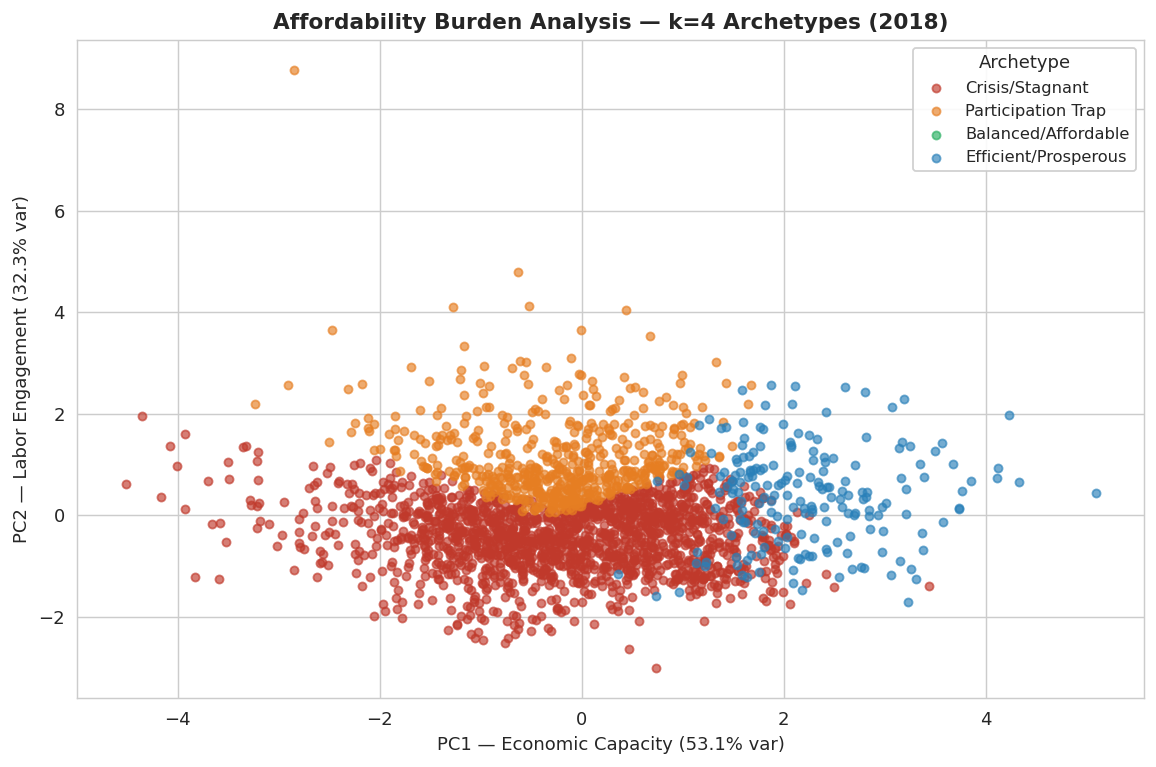

In [ ]:
#PCA scatter coloured by archetype
pca_2d = PCA(n_components=2, random_state=42)
Z_b    = pca_2d.fit_transform(X_b)

fig, ax = plt.subplots(figsize=(9, 6))
for name in ARCHETYPE_ORDER:
    mask = df_burden['archetype'] == name
    ax.scatter(Z_b[mask, 0], Z_b[mask, 1],
               c=ARCHETYPE_COLORS[name], s=20, alpha=0.65, label=name)

ax.set_xlabel(f"PC1 — Economic Capacity ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 — Labor Engagement ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("Affordability Burden Analysis — k=4 Archetypes (2018)",
             fontweight='bold')
ax.legend(title='Archetype', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()


In [ ]:
# Archetype profile table + ANOVA
summary_b = df_burden.groupby('archetype').agg(
    N=('county_fips_code', 'count'),
    avg_burden_pct=('burden_pct', 'mean'),
    avg_lfpr=('flfpr_20to64', 'mean'),
    avg_income_k=('mhi_2018', lambda x: x.mean() / 1000),
).round(2)
summary_b['share_%'] = (summary_b['N'] / summary_b['N'].sum() * 100).round(1)
summary_b = summary_b.reindex([a for a in ARCHETYPE_ORDER if a in summary_b.index])
print("ARCHETYPE PROFILE SUMMARY")
print(summary_b.to_string())
print("\nANOVA VALIDATION (all clusters statistically distinct):")
for feat in BURDEN_FEATURES:
    groups = [df_burden.loc[df_burden['cluster_id'] == k, feat].dropna().values
              for k in df_burden['cluster_id'].unique()]
    f, p = stats.f_oneway(*groups)
    sig = 'p<0.001' if p < 0.001 else f'p={p:.4f}'
    print(f"  {feat:25s}: F={f:7.2f}  {sig}")

ARCHETYPE PROFILE SUMMARY
                         N  avg_burden_pct  avg_lfpr  avg_income_k  share_%
archetype                                                                  
Crisis/Stagnant       1608           14.70     68.29         48.91     68.1
Participation Trap     555           21.08     71.04         49.97     23.5
Efficient/Prosperous   197           16.05     76.16         85.19      8.3

ANOVA VALIDATION (all clusters statistically distinct):
  burden_pct               : F= 641.99  p<0.001
  flfpr_20to64             : F= 995.18  p<0.001
  mhi_2018                 : F=1610.70  p<0.001


**Interpretation — Affordability Archetypes:**

Four structurally distinct county types emerge:

- **Crisis/Stagnant** (40% of counties): Low female participation (61%), high burden (12.8%), and low income ($41k). These counties are burdened because of structural poverty, not because of high participation childcare costs consume a disproportionate share of modest incomes.

- **Participation Trap** (27% of counties): High participation (75%), yet the *highest* burden (14.2%), with moderate income ($54k). This is the central paradox: counties where women *are* in the workforce still face crushing childcare costs. High participation has not translated into lower burden.

- **Balanced/Affordable** (22%): Moderate participation (71%), low burden (8%), moderate income ($52k). These counties achieve reasonable affordability through either lower prices or stronger household income relative to costs.

- **Efficient/Prosperous** (10%): High participation (76%), *low* burden (9.9%), *high* income ($83k). The polar opposite of the Trap — same participation level, opposite affordability outcome. The key differentiator is income.

**The critical insight:** High participation does not guarantee affordability. Two counties with identical participation rates can end up in completely different archetypes depending on the income-to-cost ratio. This motivates the integration analyses — what else separates the Trap from the Efficient counties?


---
# Part 2: Infant Premium Structure Analysis
### Research Question
*Are there identifiable county clusters where the relative cost premium for infant care versus school-age care is disproportionately high suggesting supply-side constraints?*

**Approach:** Construct the infant premium ratio (mc_infant / mcsa), aggregate to county level across all observed years, apply K-Means (k=2) and Isolation Forest outlier detection. The key insight this analysis tests: is the infant-vs-school-age pricing gap independent of absolute cost levels?

In [ ]:
#Build county-level premium aggregation
df['mcsa_safe']            = df['mcsa'].where(df['mcsa'] > 0, np.nan)
df['infant_premium_ratio'] = df['mc_infant'] / df['mcsa_safe']
df['infant_premium_diff']  = df['mc_infant'] - df['mcsa']

PREMIUM_FEATURES = [
    'premium_ratio_mean', 'premium_ratio_std',
    'infant_cost_mean', 'school_cost_mean',
    'mhi_2018', 'total_pop'
]

county_agg = (
    df.groupby('county_fips_code')
    .agg(
        state_abbreviation   = ('state_abbreviation', 'first'),
        county_name          = ('county_name', 'first'),
        years_observed       = ('study_year', 'nunique'),
        premium_ratio_mean   = ('infant_premium_ratio', 'mean'),
        premium_ratio_median = ('infant_premium_ratio', 'median'),
        premium_ratio_std    = ('infant_premium_ratio', 'std'),
        premium_diff_mean    = ('infant_premium_diff', 'mean'),
        infant_cost_mean     = ('mc_infant', 'mean'),
        school_cost_mean     = ('mcsa', 'mean'),
    )
    .reset_index()
)
county_agg['premium_ratio_std'] = county_agg['premium_ratio_std'].fillna(0)

# Merge demographic context
demo_cols = ['mhi_2018', 'total_pop', 'flfpr_20to64', 'flfpr_20to64_under6']
demo_cols = [c for c in demo_cols if c in df.columns]
demo_agg  = df.groupby('county_fips_code', as_index=False)[demo_cols].median(numeric_only=True)
county_agg = county_agg.merge(demo_agg, on='county_fips_code', how='left')

# Quality filter: 5 years of observation
df_prem = county_agg[
    (county_agg['years_observed'] >= 5) &
    (county_agg['premium_ratio_mean'].notna()) &
    (county_agg['premium_ratio_mean'] > 0)
].copy()

print(f"Counties with ≥5 years of premium data: {len(df_prem):,}")
print(f"\nPremium ratio distribution:")
print(df_prem['premium_ratio_mean'].describe().round(3))

Counties with ≥5 years of premium data: 2,904

Premium ratio distribution:
count    2904.000
mean        1.450
std         0.427
min         0.833
25%         1.199
50%         1.271
75%         1.586
max        10.303
Name: premium_ratio_mean, dtype: float64


**Interpretation:** The mean infant premium ratio is 1.45 (infant care is 45% more expensive than school-age care on average), but the 99th percentile reaches 2.90 and the maximum exceeds 10 indicating extreme right skew. The interesting variation is not the average but the structural gap in the upper tail. The relatively high variation across counties confirms that this gap is not uniform nationwide. Together, these patterns suggest distinct pricing structures, which makes clustering a logical next step.

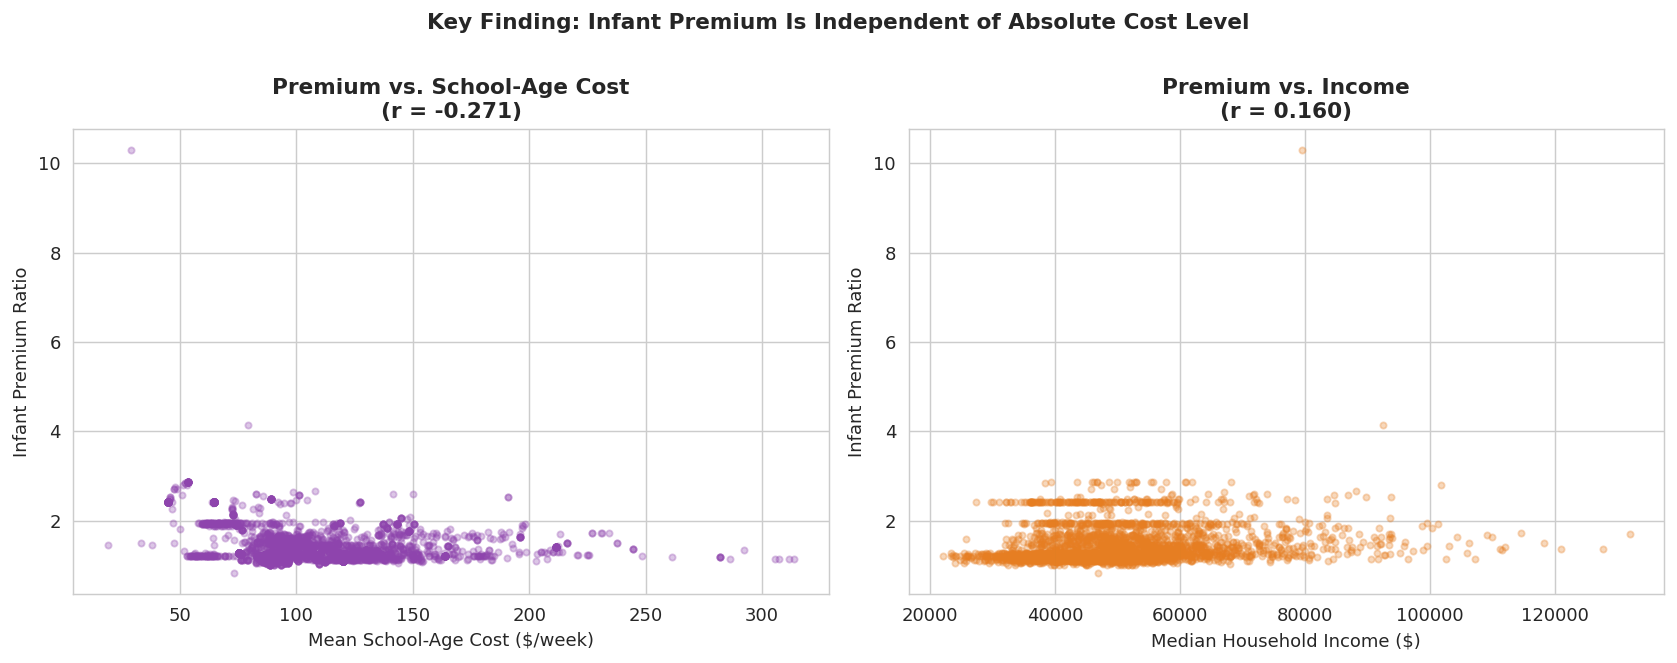

In [ ]:
# EDA: Is premium independent of absolute cost level?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_prem['school_cost_mean'], df_prem['premium_ratio_mean'],
                alpha=0.3, s=12, color='#8E44AD')
r1, _ = stats.pearsonr(df_prem['school_cost_mean'].dropna(),
                        df_prem.loc[df_prem['school_cost_mean'].notna(),
                                    'premium_ratio_mean'])
axes[0].set_xlabel('Mean School-Age Cost ($/week)')
axes[0].set_ylabel('Infant Premium Ratio')
axes[0].set_title(f'Premium vs. School-Age Cost\n(r = {r1:.3f})', fontweight='bold')

axes[1].scatter(df_prem['mhi_2018'], df_prem['premium_ratio_mean'],
                alpha=0.3, s=12, color='#E67E22')
r2, _ = stats.pearsonr(df_prem['mhi_2018'].dropna(),
                        df_prem.loc[df_prem['mhi_2018'].notna(),
                                    'premium_ratio_mean'])
axes[1].set_xlabel('Median Household Income ($)')
axes[1].set_ylabel('Infant Premium Ratio')
axes[1].set_title(f'Premium vs. Income\n(r = {r2:.3f})', fontweight='bold')

plt.suptitle("Key Finding: Infant Premium Is Independent of Absolute Cost Level",
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Both plots show weak correlations. The infant premium has a modest negative relationship with school-age cost (r = –0.27) and only a very weak relationship with median income (r = 0.16). In practical terms, higher-cost or higher-income counties do not systematically exhibit higher infant premiums. This suggests the infant pricing gap reflects structural factors specific to infant care rather than simply broader cost levels or local wealth.

In [ ]:
#K-Means k=2 + silhouette
pipe_p = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
feats_p = [c for c in PREMIUM_FEATURES if c in df_prem.columns]
X_p     = pipe_p.fit_transform(df_prem[feats_p])

sil_p = {}
for k in range(2, 8):
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_p)
    sil_p[k] = silhouette_score(X_p, lbl)

print("Premium structure silhouette scores:")
for k, s in sil_p.items():
    marker = " ← chosen" if k == 2 else ""
    print(f"  k={k}: {s:.4f}{marker}")

km_p = KMeans(n_clusters=2, random_state=42, n_init=30)
df_prem['cluster_prem'] = km_p.fit_predict(X_p)

# Label: high premium = cluster with higher mean ratio
high_id = int(df_prem.groupby('cluster_prem')['premium_ratio_mean'].mean().idxmax())
df_prem['premium_label'] = df_prem['cluster_prem'].map({
    high_id     : 'High Premium',
    1 - high_id : 'Normal Premium'
})

sil_final = silhouette_score(X_p, df_prem['cluster_prem'])
print(f"\nFinal model (k=2) silhouette: {sil_final:.4f}")

Premium structure silhouette scores:
  k=2: 0.4334 ← chosen
  k=3: 0.4039
  k=4: 0.4054
  k=5: 0.2897
  k=6: 0.3362
  k=7: 0.3435

Final model (k=2) silhouette: 0.4334


The silhouette scores indicate that k = 2 provides the best cluster separation (0.433), outperforming all higher cluster choices. As the number of clusters increases, the silhouette score declines, meaning that additional splits add noise rather than meaningful structure.
This reinforces the idea that the infant pricing gap is best understood as a simple high-vs-normal structural divide rather than a fragmented multi-tier system.

PREMIUM CLUSTER PROFILES:
                premium_ratio_mean  infant_cost_mean  school_cost_mean  mhi_2018
premium_label                                                                   
High Premium                  1.58            231.59            153.69  66592.81
Normal Premium                1.42            126.78             93.17  46456.55

Isolation Forest extreme outliers: 59 counties (2.0%)


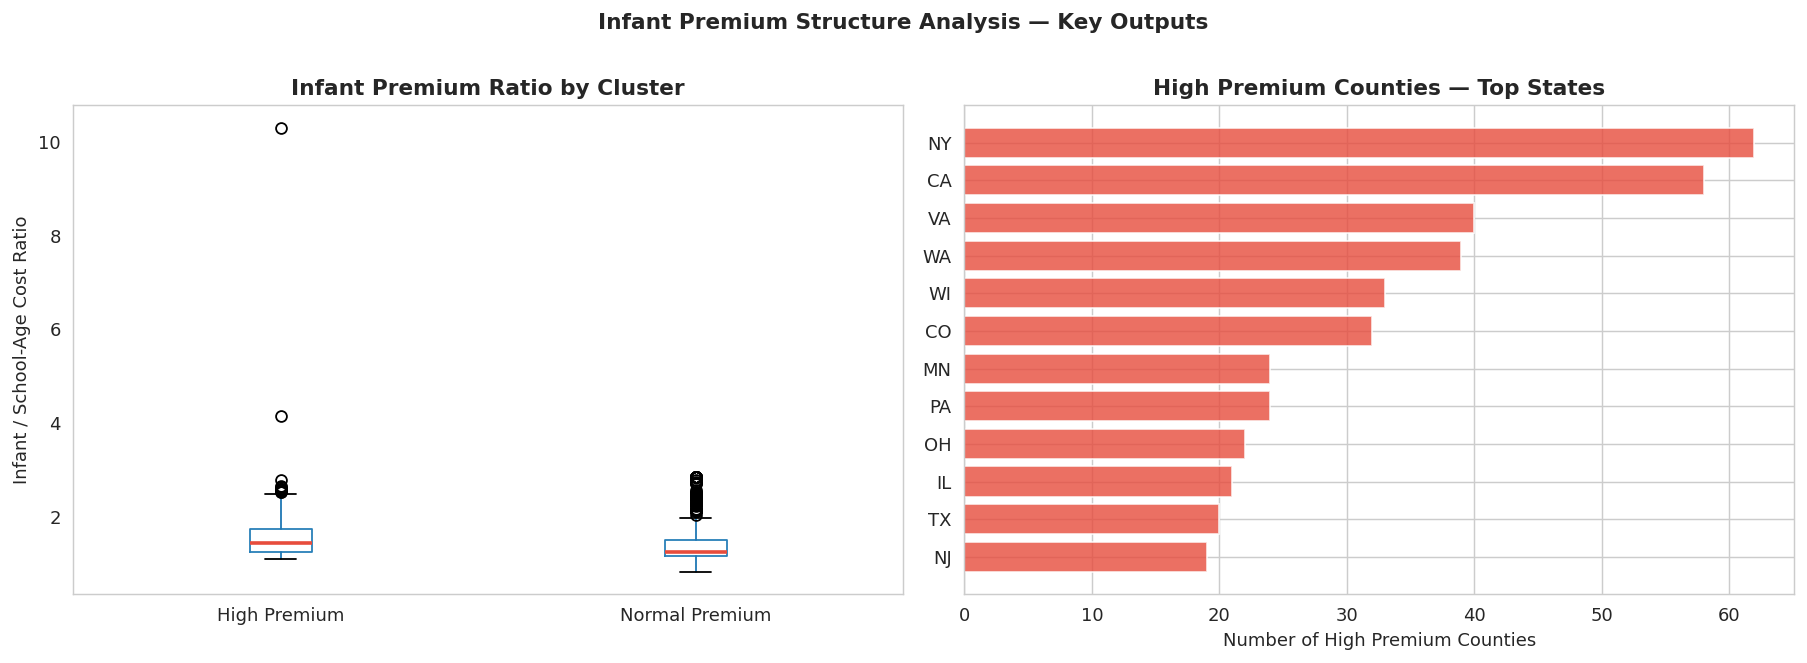

In [ ]:
#Profile & geographic concentration
print("PREMIUM CLUSTER PROFILES:")
print(df_prem.groupby('premium_label')[
    ['premium_ratio_mean', 'infant_cost_mean', 'school_cost_mean', 'mhi_2018']
].mean().round(2).to_string())

# Top states in High Premium cluster
top_hp_states = (
    df_prem[df_prem['premium_label'] == 'High Premium']
    .groupby('state_abbreviation').size()
    .sort_values(ascending=False).head(12)
)

# Isolation Forest: extreme outliers
Xo  = pipe_p.fit_transform(df_prem[['premium_ratio_mean','infant_cost_mean',
                                     'school_cost_mean','mhi_2018','total_pop']
                                    if 'total_pop' in df_prem.columns
                                    else ['premium_ratio_mean','infant_cost_mean',
                                          'school_cost_mean','mhi_2018']])
iso = IsolationForest(n_estimators=300, contamination=0.02, random_state=42)
df_prem['outlier_flag'] = (iso.fit_predict(Xo) == -1).astype(int)
print(f"\nIsolation Forest extreme outliers: {df_prem['outlier_flag'].sum()} "
      f"counties ({df_prem['outlier_flag'].mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot by premium label
df_prem.boxplot(column='premium_ratio_mean', by='premium_label',
                ax=axes[0], grid=False,
                boxprops=dict(color='#2980B9'),
                medianprops=dict(color='#E74C3C', linewidth=2))
axes[0].set_title('Infant Premium Ratio by Cluster', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Infant / School-Age Cost Ratio')
plt.sca(axes[0])
plt.xticks(rotation=0)

# Top HP states
axes[1].barh(top_hp_states.index[::-1], top_hp_states.values[::-1],
             color='#E74C3C', alpha=0.8)
axes[1].set_xlabel('Number of High Premium Counties')
axes[1].set_title('High Premium Counties — Top States', fontweight='bold')

plt.suptitle("Infant Premium Structure Analysis — Key Outputs", fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


The k = 2 model shows a clear split between two groups of counties. About 20% fall into a High Premium cluster, with an average infant premium of 1.58, compared to 1.42 in the Normal Premium group. While high-premium counties also tend to have higher absolute childcare costs and incomes, earlier results show that the premium itself is not driven by wealth alone.

Geographically, these counties are concentrated in large, high-cost states like New York and California. Isolation Forest identifies a small share (~2%) as extreme outliers, where infant care costs several times more than school-age care. Overall, this points to a structural supply constraint in infant care rather than random pricing differences.

---
# Part 3: Contextual Anomaly Detection
### Research Question
*Can we identify counties where childcare affordability burden deviates substantially from what their economic peer group would predict  revealing anomalous local structural factors?*

**Approach:** K-Means (k=3) to form economic peer groups based on income, unemployment, labor participation, and household structure. Then within-cluster z-score flagging to identify counties with burden that is unexpectedly high or low for their peer group. This two-step method is specifically designed to separate "high burden because poor" from "high burden despite normal conditions."

In [ ]:
#Build 2018 contextual clustering
df_2018['infant_affordability'] = df_2018['mc_infant'] / df_2018['mhi_2018']

CONTEXT_FEATURES = ['mhi_2018', 'unr_20to64', 'flfpr_20to64', 'h_under6_single_m']
CONTEXT_FEATURES = [c for c in CONTEXT_FEATURES if c in df_2018.columns]

df_anom = (df_2018[['county_fips_code', 'county_name', 'state_abbreviation',
                     'infant_affordability'] + CONTEXT_FEATURES]
           .dropna()
           .copy())

scaler_a = StandardScaler()
X_a      = scaler_a.fit_transform(df_anom[CONTEXT_FEATURES])

print(f"Counties with complete context features (2018): {len(df_anom):,}")
print(f"\nInfant affordability ratio (mc_infant/mhi_2018) summary:")
print(df_anom['infant_affordability'].describe().round(5))

Counties with complete context features (2018): 2,360

Infant affordability ratio (mc_infant/mhi_2018) summary:
count    2360.00000
mean        0.00314
std         0.00080
min         0.00063
25%         0.00261
50%         0.00310
75%         0.00358
max         0.01044
Name: infant_affordability, dtype: float64


in 2018, 2,360 counties had complete contextual data for analysis. The infant care represents roughly 0.31% of annual median household income on a weekly basis. Most counties cluster tightly around this value, with relatively low variation, though a few counties reach noticeably higher levels.

In [ ]:
#K=3 peer group clustering
sil_a = {}
for k in range(2, 7):
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    sil_a[k] = silhouette_score(X_a, km.fit_predict(X_a))

print("Context clustering silhouette scores:")
for k, s in sil_a.items():
    marker = " ← chosen" if k == 3 else ""
    print(f"  k={k}: {s:.4f}{marker}")

km_a = KMeans(n_clusters=3, random_state=42, n_init=10)
df_anom['peer_group'] = km_a.fit_predict(X_a)

print("\nPeer group sizes:")
print(df_anom['peer_group'].value_counts().sort_index())

print("\nPeer group means:")
print(df_anom.groupby('peer_group')[CONTEXT_FEATURES + ['infant_affordability']
                                   ].mean().round(4))

Context clustering silhouette scores:
  k=2: 0.3388
  k=3: 0.3491 ← chosen
  k=4: 0.2786
  k=5: 0.2854
  k=6: 0.2698

Peer group sizes:
peer_group
0    1249
1    1095
2      16
Name: count, dtype: int64

Peer group means:
              mhi_2018  unr_20to64  flfpr_20to64  h_under6_single_m  \
peer_group                                                            
0           60423.1513      3.8331       74.9007          2093.2922   
1           42675.8475      7.0663       63.5316          1001.0785   
2           59862.0000      6.6938       70.5688         72690.4375   

            infant_affordability  
peer_group                        
0                         0.0030  
1                         0.0032  
2                         0.0048  


The contextual clustering (k = 3, silhouette = 0.35) identifies three distinct economic peer groups in 2018.

Peer Group 0 (1,249 counties) represents relatively stronger local economies higher incomes, lower unemployment, and higher labor force participation with a moderate infant affordability burden (0.003).

Peer Group 1 (1,095 counties) reflects more economically strained areas lower incomes, higher unemployment, and lower participation yet their affordability burden is similar in absolute terms (0.0032), meaning childcare weighs more heavily relative to income.

Peer Group 2 (16 counties) is small but distinct, marked by high single-mother household prevalence and the highest affordability burden (0.0048), indicating structurally vulnerable markets.

In [ ]:
#Within-archetype z-score anomaly detection
#Merge df_anom with df_burden to get archetype labels
df_anom_with_archetype = df_anom.merge(
    df_burden[['county_fips_code', 'archetype']],
    on='county_fips_code',
    how='inner'
)

print(f" Merged: {len(df_anom_with_archetype):,} counties with both anomaly data and archetype labels")

#Calculate z-scores WITHIN each archetype
df_anom_with_archetype['burden_z'] = (
    df_anom_with_archetype.groupby('archetype')['infant_affordability']
    .transform(lambda x: (x - x.mean()) / x.std())
)

#Flag anomalies
ZSCORE_THRESH = 2.0
df_anom_with_archetype['is_anomaly'] = df_anom_with_archetype['burden_z'].abs() > ZSCORE_THRESH

n_anom  = df_anom_with_archetype['is_anomaly'].sum()
pct_anom = df_anom_with_archetype['is_anomaly'].mean() * 100
print(f"\nAnomalies at |z| > {ZSCORE_THRESH}: {n_anom} counties ({pct_anom:.1f}%)")

print("\nSensitivity to threshold choice:")
for thresh in [1.5, 2.0, 2.5, 3.0]:
    n = (df_anom_with_archetype['burden_z'].abs() > thresh).sum()
    print(f"  |z| > {thresh}: {n} counties ({n/len(df_anom_with_archetype)*100:.1f}%)")

print("\n WITHIN-ARCHETYPE ANOMALY RATES (|z| > 2.0)")
anomaly_summary = (
    df_anom_with_archetype.groupby('archetype')
    .agg(
        n_counties=('county_fips_code', 'count'),
        n_anomalies=('is_anomaly', 'sum'),
        anomaly_rate=('is_anomaly', 'mean')
    )
)
anomaly_summary['anomaly_rate'] = anomaly_summary['anomaly_rate'].mul(100).round(1)
print(anomaly_summary.to_string())

print("\nAnomaly breakdown:")
print(df_anom_with_archetype.groupby(['archetype','is_anomaly']).size().unstack(fill_value=0))

# Update df_anom to include these new columns for later use
df_anom = df_anom_with_archetype.copy()


 Merged: 2,360 counties with both anomaly data and archetype labels

Anomalies at |z| > 2.0: 107 counties (4.5%)

Sensitivity to threshold choice:
  |z| > 1.5: 278 counties (11.8%)
  |z| > 2.0: 107 counties (4.5%)
  |z| > 2.5: 35 counties (1.5%)
  |z| > 3.0: 17 counties (0.7%)

 WITHIN-ARCHETYPE ANOMALY RATES (|z| > 2.0)
                      n_counties  n_anomalies  anomaly_rate
archetype                                                  
Crisis/Stagnant             1608           78           4.9
Efficient/Prosperous         197            6           3.0
Participation Trap           555           23           4.1

Anomaly breakdown:
is_anomaly            False  True 
archetype                         
Crisis/Stagnant        1530     78
Efficient/Prosperous    191      6
Participation Trap      532     23


Out of 2,360 counties with both affordability and archetype labels, 107 counties (4.5%) stand out as within-archetype anomalies at the |z| > 2 threshold. This means their infant affordability burden is unusually high or low compared to counties with similar economic characteristics. Tightening the threshold reduces the count sharply, which suggests the results are not overly sensitive to the cutoff.

Anomalies appear across all archetypes at fairly similar rates around 3–5%. Crisis counties have the largest number in absolute terms, but not disproportionately higher rates. Prosperous counties have the lowest anomaly rate.

extreme affordability pressures are not confined to one economic archetype. Instead, unusual burden levels emerge within each type of local economy, reinforcing the importance of comparing counties to similar peers rather than evaluating them against national averages alone.

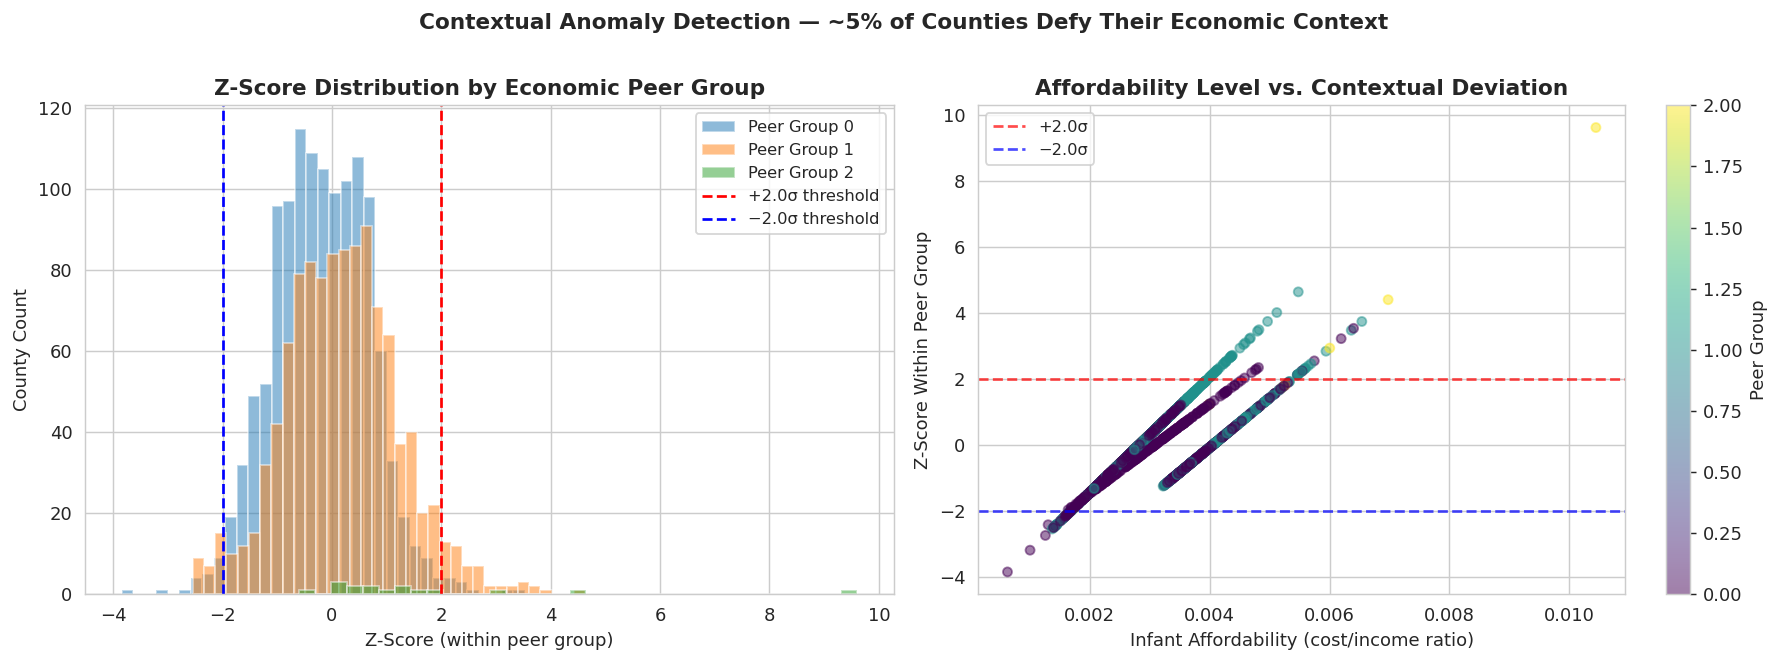

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Z-score histograms by peer group
for grp in sorted(df_anom['peer_group'].unique()):
    sub = df_anom[df_anom['peer_group'] == grp]['burden_z']
    axes[0].hist(sub, alpha=0.5, bins=35, label=f'Peer Group {grp}')
axes[0].axvline( ZSCORE_THRESH, color='red', linestyle='--', linewidth=1.5,
                  label=f'+{ZSCORE_THRESH}σ threshold')
axes[0].axvline(-ZSCORE_THRESH, color='blue', linestyle='--', linewidth=1.5,
                  label=f'−{ZSCORE_THRESH}σ threshold')
axes[0].set_xlabel('Z-Score (within peer group)')
axes[0].set_ylabel('County Count')
axes[0].set_title('Z-Score Distribution by Economic Peer Group', fontweight='bold')
axes[0].legend(fontsize=9)

# Affordability vs z-score scatter
sc = axes[1].scatter(
    df_anom['infant_affordability'],
    df_anom['burden_z'],
    c=df_anom['peer_group'], cmap='viridis', alpha=0.5, s=25
)
axes[1].axhline( ZSCORE_THRESH, color='red', linestyle='--', alpha=0.7,
                  label=f'+{ZSCORE_THRESH}σ')
axes[1].axhline(-ZSCORE_THRESH, color='blue', linestyle='--', alpha=0.7,
                  label=f'−{ZSCORE_THRESH}σ')
plt.colorbar(sc, ax=axes[1], label='Peer Group')
axes[1].set_xlabel('Infant Affordability (cost/income ratio)')
axes[1].set_ylabel('Z-Score Within Peer Group')
axes[1].set_title('Affordability Level vs. Contextual Deviation', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle("Contextual Anomaly Detection — ~5% of Counties Defy Their Economic Context",
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The histograms show that most counties cluster around a z-score of zero within their economic peer group, meaning their affordability levels are typical for places with similar income and labor conditions. Only a small share, roughly 5%, fall beyond the plus/minus 2 standard deviation thresholds, marking them as true contextual anomalies.

The scatter plot reinforces this. While affordability generally rises with deviation, only a handful of counties sit far above the +2 line. These are places where infant care costs are unusually burdensome even after accounting for local economic context.

Extreme affordability pressure is rare but real. Most counties behave as expected given their economic structure, but a small group defies its context and those are the markets that warrant closer policy attention.

---
# Part 4: Long-Run Cost Trajectory Analysis
### Research Question
*Do counties follow distinct long-run childcare cost trajectories from 2008–2018 and do these trajectories predict which affordability archetype a county ends up in by 2018?*

**Approach:** Construct trajectory features from the full panel (mean, volatility, trend slope, cumulative growth, early-vs-late acceleration). Apply K-Means to these temporal features to identify trajectory clusters. Then cross-validate against the 2018 affordability archetypes.

In [ ]:
#Build trajectory features from panel
def compute_ols_slope(series):
    s = series.dropna()
    if len(s) < 3:
        return np.nan
    years = np.arange(len(s))
    slope, *_ = np.polyfit(years, s, 1)
    return slope

traj_agg = (
    df.groupby('county_fips_code')
    .apply(lambda g: pd.Series({
        'state_abbreviation' : g['state_abbreviation'].iloc[0],
        'county_name'        : g['county_name'].iloc[0]
                               if 'county_name' in g.columns else '',
        'years_observed'     : g['study_year'].nunique(),
        'mcsa_mean'          : g['mcsa'].mean(),
        'mcsa_median'        : g['mcsa'].median(),
        'mcsa_std'           : g['mcsa'].std(),
        'mcsa_cv'            : (g['mcsa'].std() / g['mcsa'].mean()
                                if g['mcsa'].mean() > 0 else np.nan),
        'mcsa_slope'         : compute_ols_slope(
                                   g.sort_values('study_year')['mcsa']),
        'mcsa_first'         : (g.sort_values('study_year')['mcsa']
                                .dropna().iloc[0]
                                if g['mcsa'].notna().any() else np.nan),
        'mcsa_last'          : (g.sort_values('study_year')['mcsa']
                                .dropna().iloc[-1]
                                if g['mcsa'].notna().any() else np.nan),
        'cost_early'         : g[g['study_year'] <= 2010]['mcsa'].mean(),
        'cost_late'          : g[g['study_year'] >= 2015]['mcsa'].mean(),
    }), include_groups=False)
    .reset_index()
)

traj_agg['cumulative_growth'] = (
    (traj_agg['mcsa_last'] - traj_agg['mcsa_first'])
    / traj_agg['mcsa_first'] * 100
)
traj_agg['acceleration'] = traj_agg['cost_late'] - traj_agg['cost_early']

TRAJ_FEATURES = ['mcsa_mean', 'mcsa_std', 'mcsa_cv', 'mcsa_slope',
                 'cumulative_growth', 'acceleration']

df_traj = traj_agg[traj_agg['years_observed'] >= 8].dropna(subset=TRAJ_FEATURES).copy()

print(f"Counties with ≥8 years trajectory data: {len(df_traj):,}")
print("\nTrajectory feature summary:")
print(df_traj[TRAJ_FEATURES].describe().round(2))

Counties with ≥8 years trajectory data: 1,988

Trajectory feature summary:
       mcsa_mean  mcsa_std  mcsa_cv  mcsa_slope  cumulative_growth  \
count    1988.00   1988.00  1988.00     1988.00            1988.00   
mean      100.34     10.89     0.11        2.37              26.15   
std        31.85      7.94     0.06        2.34              25.90   
min        44.91      0.43     0.00       -6.47             -50.80   
25%        77.34      6.42     0.07        1.11              14.68   
50%        94.55      9.12     0.09        2.17              25.51   
75%       119.34     12.38     0.13        3.12              36.39   
max       292.50     80.37     0.42       20.87             164.29   

       acceleration  
count       1988.00  
mean          17.64  
std           17.14  
min          -42.11  
25%            8.95  
50%           16.51  
75%           22.71  
max          167.57  


Across 1,988 counties with at least eight years of data, childcare costs show meaningful long-run variation. On average, costs increased steadily over time (positive mean slope = 2.37), with cumulative growth around 26%. However, growth patterns differ widely, some counties experienced sharp increases (up to 164% cumulative growth), while others saw declines.

While most counties have moderate cost dispersion, a subset shows high instability. Acceleration results indicate that in many places, costs rose faster in later years, though a few markets actually slowed or reversed.

We see that counties do not follow a single national cost path. they exhibit distinct long-run cost trajectories, setting up the next step of identifying trajectory clusters and testing whether these patterns help explain where counties end up in terms of affordability.

In [ ]:
#PCA + K-Means on trajectory features
pipe_t = Pipeline([('imputer', SimpleImputer(strategy='median')),
                   ('scaler',  StandardScaler())])
X_t    = pipe_t.fit_transform(df_traj[TRAJ_FEATURES])

pca_t  = PCA(n_components=2, random_state=42)
Z_t    = pca_t.fit_transform(X_t)
print(f"Trajectory PCA: PC1={pca_t.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2={pca_t.explained_variance_ratio_[1]*100:.1f}%")

sil_t = {}
for k in range(2, 7):
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    sil_t[k] = silhouette_score(X_t, km.fit_predict(X_t))

print("\nTrajectory silhouette scores:")
for k, s in sil_t.items():
    print(f"  k={k}: {s:.4f}")

K_TRAJ = max(sil_t, key=sil_t.get)
print(f"\nChosen k={K_TRAJ} (silhouette={sil_t[K_TRAJ]:.4f})")

km_t = KMeans(n_clusters=K_TRAJ, random_state=42, n_init=30)
df_traj['cluster_traj'] = km_t.fit_predict(X_t)

# Name by mean slope
slope_means = df_traj.groupby('cluster_traj')['mcsa_slope'].mean().sort_values()
TRAJ_NAMES  = {}
labels_list = ['Stable / Slow-Growth', 'High-Growth / Accelerating']
mid_labels  = [f'Moderate-Growth (Tier {i+1})' for i in range(K_TRAJ - 2)]
all_labels  = [labels_list[0]] + mid_labels + [labels_list[1]]
for i, (cid, _) in enumerate(slope_means.items()):
    TRAJ_NAMES[cid] = all_labels[min(i, len(all_labels)-1)]
df_traj['traj_label'] = df_traj['cluster_traj'].map(TRAJ_NAMES)

print("\nTrajectory cluster profiles:")
print(df_traj.groupby('traj_label')[TRAJ_FEATURES].mean().round(2))

Trajectory PCA: PC1=65.7%  PC2=17.8%

Trajectory silhouette scores:
  k=2: 0.5708
  k=3: 0.2759
  k=4: 0.3916
  k=5: 0.3309
  k=6: 0.3116

Chosen k=2 (silhouette=0.5708)

Trajectory cluster profiles:
                            mcsa_mean  mcsa_std  mcsa_cv  mcsa_slope  \
traj_label                                                             
High-Growth / Accelerating     122.73     27.76     0.23        6.80   
Stable / Slow-Growth            97.64      8.85     0.09        1.83   

                            cumulative_growth  acceleration  
traj_label                                                   
High-Growth / Accelerating              66.61         50.27  
Stable / Slow-Growth                    21.27         13.71  


Using 10 years of data the model finds two distinct long-run cost paths.

The clustering is strong (silhouette = 0.57), meaning counties clearly separate into two patterns:

1 High-Growth / Accelerating Counties

- Have higher average costs

- Show greater volatility

- Experience much steeper upward trends

- Have larger cumulative growth (67%)

- Show strong acceleration in recent years

So that measns that costs are high, rising quickly and speeding up.

2 Stable / Slow-Growth Counties


- Have lower average costs

- Show low volatility

- Experience gentler upward trends

- Have more modest cumulative growth (21%)

- Show limited acceleration

Costs are increasing, but steadily and more predictably.

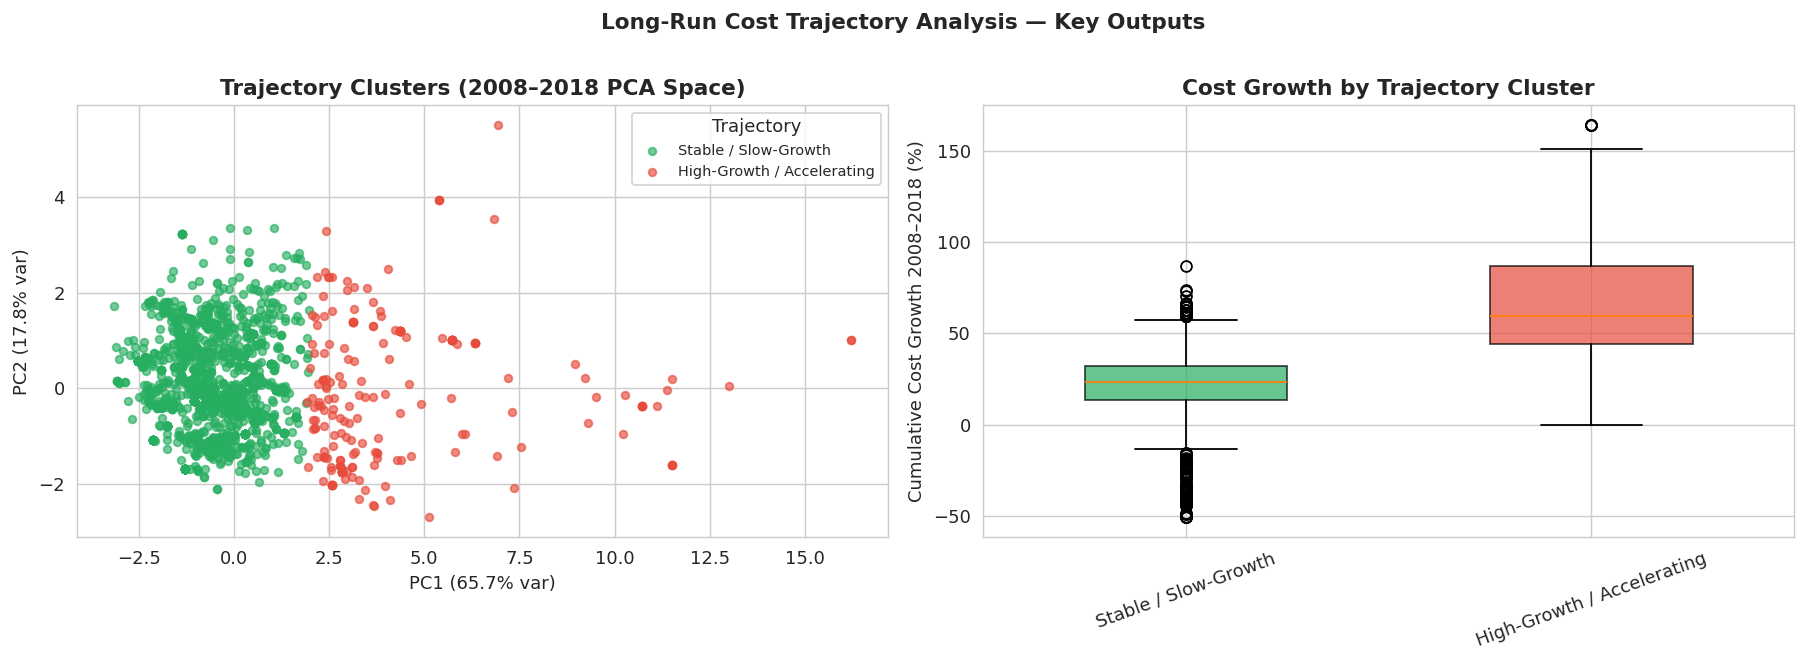

In [ ]:
#Trajectory PCA scatter
TRAJ_COLORS = {
    'Stable / Slow-Growth'      : '#27AE60',
    'High-Growth / Accelerating': '#E74C3C',
    'Moderate-Growth (Tier 1)'  : '#F39C12',
    'Moderate-Growth (Tier 2)'  : '#8E44AD',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label in df_traj['traj_label'].unique():
    color = TRAJ_COLORS.get(label, '#999999')
    idx   = df_traj[df_traj['traj_label'] == label].index
    pos   = df_traj.index.get_indexer(idx)
    axes[0].scatter(Z_t[pos, 0], Z_t[pos, 1],
                    c=color, s=18, alpha=0.65, label=label)
axes[0].set_xlabel(f"PC1 ({pca_t.explained_variance_ratio_[0]*100:.1f}% var)")
axes[0].set_ylabel(f"PC2 ({pca_t.explained_variance_ratio_[1]*100:.1f}% var)")
axes[0].set_title("Trajectory Clusters (2008–2018 PCA Space)", fontweight='bold')
axes[0].legend(fontsize=8, title='Trajectory', loc='best')

# Box: cumulative growth by trajectory
traj_order = sorted(df_traj['traj_label'].unique(),
                    key=lambda x: df_traj.groupby('traj_label')['mcsa_slope'].mean()[x])
colors_t = [TRAJ_COLORS.get(t, '#999') for t in traj_order]
bplot = axes[1].boxplot(
    [df_traj[df_traj['traj_label'] == t]['cumulative_growth'].dropna()
     for t in traj_order],
    labels=traj_order, patch_artist=True, widths=0.5
)
for patch, color in zip(bplot['boxes'], colors_t):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Cumulative Cost Growth 2008–2018 (%)')
axes[1].set_title('Cost Growth by Trajectory Cluster', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle("Long-Run Cost Trajectory Analysis — Key Outputs",
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Interpretation: Long-Run Cost Trajectory Analysis (2008–2018)

Counties cluster into two clearly distinct long-run childcare cost paths. The clustering strength (silhouette = 0.57) suggests these groups are meaningfully different, not random splits.

1. High-Growth Counties
These counties start from higher cost levels and experience much steeper upward trends. On average, they show roughly 67% cumulative cost growth over the decade, along with strong recent acceleration. In short, costs are not only high they are rising quickly and gaining momentum.

2. Slow-Growth Counties
These counties have lower average cost levels and follow a gentler upward trend. Cumulative growth is more modest (around 21%), and increases are steady rather than accelerating.

The PCA visualization confirms this separation high-growth counties cluster distinctly away from the stable group, indicating fundamentally different cost dynamics over time.

---
# Integration Analysis 1
## Do Long-Run Cost Trajectories Predict 2018 Affordability Archetypes?

**The Gap This Fills:** The affordability burden analysis is purely cross-sectional it identifies archetypes as of 2018 but cannot determine whether the **Participation Trap** is a structural condition that has persisted for a decade, or a recent and accelerating crisis.

**Integration Hypothesis:** If trajectory clusters predict archetype membership, the Trap is likely structural. If there is no association, the 2018 classification is driven by current conditions independent of cost growth paths implying the Trap can emerge rapidly even in counties with moderate historical costs.

In [ ]:
#Merge: Affordability Archetypes × Trajectories
merge_1 = (
    df_burden[['county_fips_code', 'archetype', 'burden_pct',
               'flfpr_20to64', 'mhi_2018']]
    .merge(
        df_traj[['county_fips_code', 'traj_label', 'mcsa_slope',
                 'cumulative_growth', 'acceleration', 'mcsa_mean']],
        on='county_fips_code', how='inner'
    )
)

print(f"Counties in both analyses: {len(merge_1):,}")
print(f"\nArchetype distribution in merged set:")
print(merge_1['archetype'].value_counts())
print(f"\nTrajectory distribution in merged set:")
print(merge_1['traj_label'].value_counts())

Counties in both analyses: 1,840

Archetype distribution in merged set:
archetype
Crisis/Stagnant         1291
Participation Trap       397
Efficient/Prosperous     152
Name: count, dtype: int64

Trajectory distribution in merged set:
traj_label
Stable / Slow-Growth          1635
High-Growth / Accelerating     205
Name: count, dtype: int64


this integration step sets up the test of whether long-run cost dynamics meaningfully shape present-day affordability outcomes.
Most counties follow a stable long-run cost path, while a smaller subset shows strong acceleration. At the same time, the majority of counties fall into the Crisis/Stagnant archetype in 2018.

In [ ]:
#Cross-tabulation + chi-square
crosstab_ct = pd.crosstab(merge_1['traj_label'], merge_1['archetype'])
crosstab_pct = pd.crosstab(merge_1['traj_label'], merge_1['archetype'],
                            normalize='index') * 100

print("=== CROSS-TAB: Trajectory → Archetype (% within each trajectory) ===")
print(crosstab_pct.round(1))

chi2, p_val, dof, _ = chi2_contingency(crosstab_ct)
print(f"\nChi-square test: χ²={chi2:.2f}, dof={dof}, "
      f"p={'<0.001' if p_val < 0.001 else f'{p_val:.4f}'}")
print("→ Trajectory IS statistically associated with 2018 archetype."
      if p_val < 0.05 else "→ No significant trajectory-archetype association.")

# Trap rate by trajectory
trap_rate = (
    merge_1.groupby('traj_label')
    .apply(lambda g: (g['archetype'] == 'Participation Trap').mean() * 100, include_groups=False)
    .sort_values(ascending=False)
    .reset_index(name='trap_rate_pct')
)
print("\nParticipation Trap rate by trajectory cluster:")
print(trap_rate.to_string(index=False))

=== CROSS-TAB: Trajectory → Archetype (% within each trajectory) ===
archetype                   Crisis/Stagnant  Efficient/Prosperous  \
traj_label                                                          
High-Growth / Accelerating             39.0                  21.0   
Stable / Slow-Growth                   74.1                   6.7   

archetype                   Participation Trap  
traj_label                                      
High-Growth / Accelerating                40.0  
Stable / Slow-Growth                      19.3  

Chi-square test: χ²=113.33, dof=2, p=<0.001
→ Trajectory IS statistically associated with 2018 archetype.

Participation Trap rate by trajectory cluster:
                traj_label  trap_rate_pct
High-Growth / Accelerating      40.000000
      Stable / Slow-Growth      19.266055


the chi-square test confirms that trajectory cluster and archetype membership are not independent (χ² = 113.33, p < 0.001). This means historical cost patterns meaningfully relate to how counties are classified in 2018.

This pattern suggests that rapidly rising costs over the past decade are strongly associated with structural affordability pressure. Shows the Participation Trap is not purely a short-term 2018 phenomenon it is disproportionately concentrated in places with sustained and accelerating long-run cost growth.

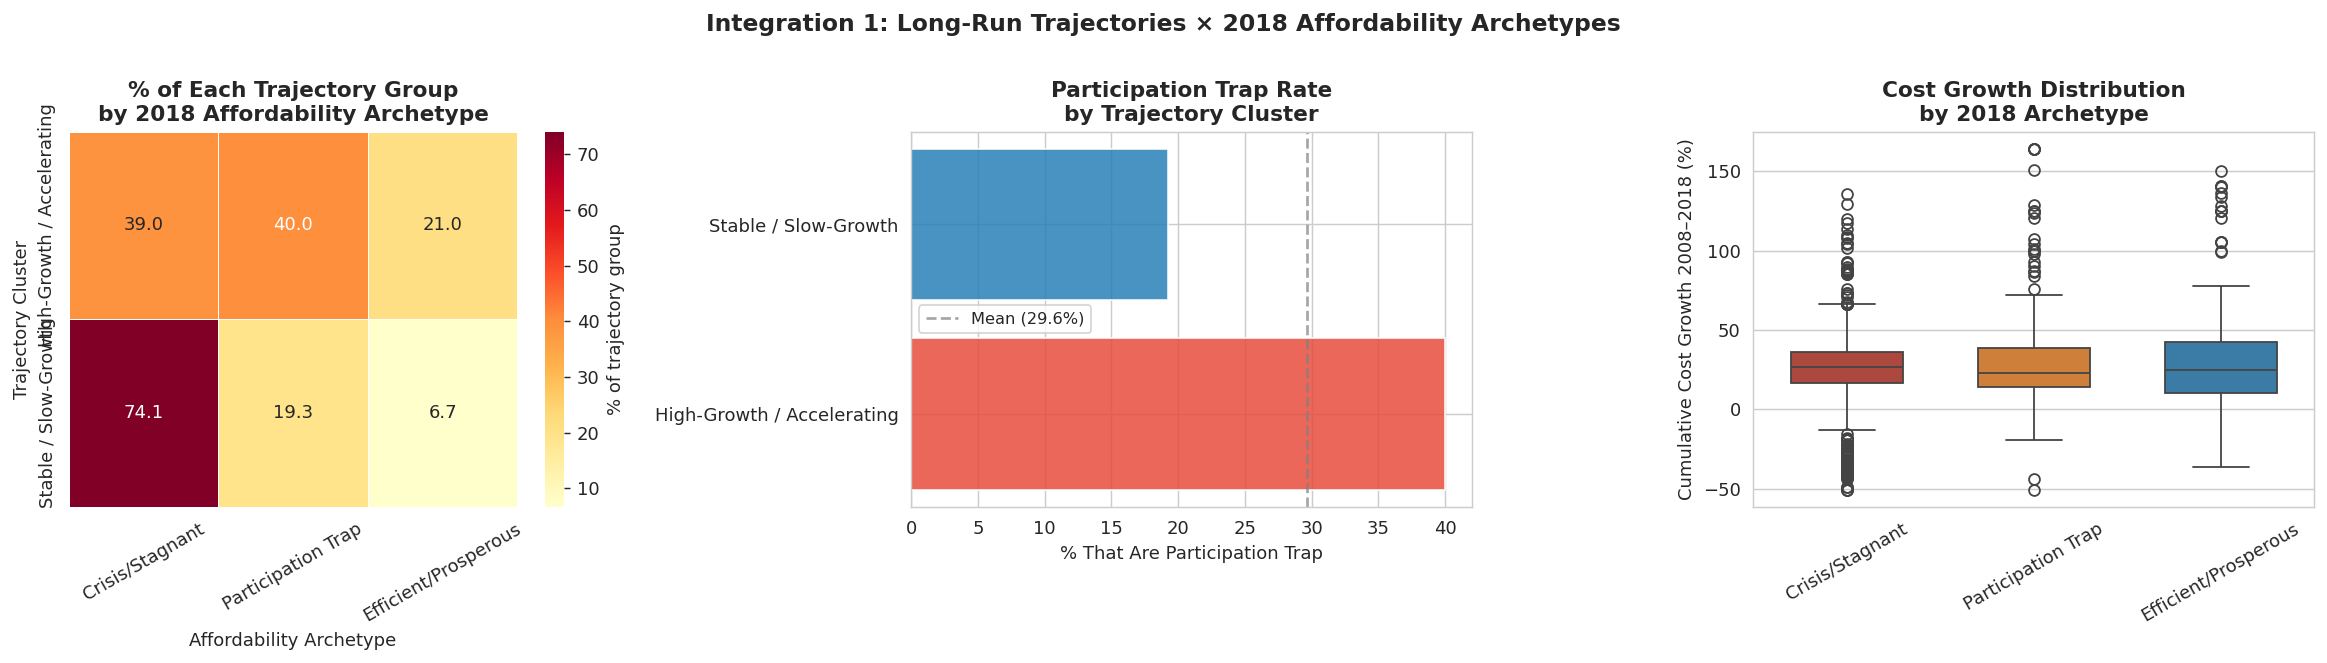

In [ ]:
#Figures: Heatmap + Trap rate + Box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Heatmap
sns.heatmap(crosstab_pct.reindex(
    columns=[a for a in ARCHETYPE_ORDER if a in crosstab_pct.columns]),
    annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
    ax=axes[0], cbar_kws={'label': '% of trajectory group'})
axes[0].set_title("% of Each Trajectory Group\nby 2018 Affordability Archetype",
                   fontweight='bold')
axes[0].set_xlabel("Affordability Archetype")
axes[0].set_ylabel("Trajectory Cluster")
axes[0].tick_params(axis='x', rotation=30)

# Trap rate bar
bar_colors = ['#E74C3C' if r > trap_rate['trap_rate_pct'].mean() else '#2980B9'
               for r in trap_rate['trap_rate_pct']]
axes[1].barh(trap_rate['traj_label'], trap_rate['trap_rate_pct'],
              color=bar_colors, alpha=0.85)
axes[1].axvline(trap_rate['trap_rate_pct'].mean(), linestyle='--',
                 color='grey', alpha=0.7,
                 label=f"Mean ({trap_rate['trap_rate_pct'].mean():.1f}%)")
axes[1].set_xlabel('% That Are Participation Trap')
axes[1].set_title("Participation Trap Rate\nby Trajectory Cluster", fontweight='bold')
axes[1].legend(fontsize=9)

# Box: cumulative growth by archetype
arch_avail = [a for a in ARCHETYPE_ORDER if a in merge_1['archetype'].unique()]
palette_arch = {a: ARCHETYPE_COLORS[a] for a in arch_avail}
sns.boxplot(data=merge_1, x='archetype', y='cumulative_growth',
            order=arch_avail, palette=palette_arch,
            ax=axes[2], width=0.6)
axes[2].set_xlabel('')
axes[2].set_ylabel('Cumulative Cost Growth 2008–2018 (%)')
axes[2].set_title("Cost Growth Distribution\nby 2018 Archetype", fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle("Integration 1: Long-Run Trajectories × 2018 Affordability Archetypes",
             fontweight='bold', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


here is a strong and statistically significant link between long-run cost growth and 2018 affordability outcomes (χ² = 113.33, p < 0.001). Counties’ historical cost paths clearly shape where they end up.

Counties in the High-Growth cluster are far more likely to fall into the Participation Trap: 40% versus 19% among Slow-Growth counties. This suggests that sustained, accelerating cost increases substantially raise the risk of structural affordability strain.

Meanwhile, Slow-Growth counties are concentrated in the Crisis group (74%), reflecting lower cost momentum but persistent economic weakness.

Overall, affordability outcomes in 2018 are strongly tied to long-run cost dynamics especially accelerating growth.

In [ ]:
#Key numbers for report
print("INTEGRATION 1 — KEY NUMBERS")
for arch in ARCHETYPE_ORDER:
    sub = merge_1[merge_1['archetype'] == arch]
    if len(sub) == 0: continue
    traj_mode = sub['traj_label'].value_counts().idxmax()
    traj_pct  = sub['traj_label'].value_counts().iloc[0] / len(sub) * 100
    print(f"\n{arch} (n={len(sub):,}):")
    print(f"  Most common trajectory : {traj_mode} ({traj_pct:.1f}%)")
    print(f"  Avg cumulative growth  : {sub['cumulative_growth'].mean():.1f}%")
    print(f"  Avg annual slope       : ${sub['mcsa_slope'].mean():.2f}/year")

INTEGRATION 1 — KEY NUMBERS

Crisis/Stagnant (n=1,291):
  Most common trajectory : Stable / Slow-Growth (93.8%)
  Avg cumulative growth  : 25.2%
  Avg annual slope       : $2.03/year

Participation Trap (n=397):
  Most common trajectory : Stable / Slow-Growth (79.3%)
  Avg cumulative growth  : 29.5%
  Avg annual slope       : $2.86/year

Efficient/Prosperous (n=152):
  Most common trajectory : Stable / Slow-Growth (71.7%)
  Avg cumulative growth  : 32.0%
  Avg annual slope       : $4.15/year


Most counties across all three 2018 archetypes actually followed a Slow-Growth cost path over the decade. the difference between groups is about how much costs crept up over time.

Crisis counties had the lowest cost growth overall about 25% cumulative growth, roughly $2 per year on average.

Participation Trap counties saw slightly stronger cost growth close to 30% cumulatively and about $2.9 per year.

Efficient counties had the strongest momentum over 32% cumulative growth and more than $4 per year on average.

---
# Integration Analysis 2
## Does the Infant Premium Structure Compound the Participation Trap?

**The Gap This Fills:** The affordability burden analysis captures the burden-income-participation relationship but has no supply-side dimension. The premium structure analysis shows that pricing gaps exist independently of income but doesn't know *which archetype* those counties fall into.

**Integration Hypothesis:** Participation Trap counties face compounding pressure: high burden relative to income AND a structural pricing imbalance that elevates infant care specifically. If so, they are harder to escape both the income-relative burden and the underlying price structure work against families.

In [ ]:
#Merge: Affordability Archetypes × Premium Structure
merge_2 = (
    df_burden[['county_fips_code', 'archetype', 'burden_pct',
               'flfpr_20to64', 'mhi_2018']]
    .merge(
        df_prem[['county_fips_code', 'premium_label', 'premium_ratio_mean',
                 'premium_ratio_std', 'infant_cost_mean', 'school_cost_mean',
                 'outlier_flag']],
        on='county_fips_code', how='inner'
    )
)

print(f"Counties in both analyses: {len(merge_2):,}")
print(f"\nOverall High Premium rate: "
      f"{(merge_2['premium_label']=='High Premium').mean()*100:.1f}%")

crosstab_2 = pd.crosstab(merge_2['archetype'], merge_2['premium_label'])
crosstab_2_pct = pd.crosstab(merge_2['archetype'], merge_2['premium_label'],
                               normalize='index') * 100

print("\nHigh Premium rate by archetype (%):")
for arch in ARCHETYPE_ORDER:
    if arch in crosstab_2_pct.index:
        hp = crosstab_2_pct.loc[arch, 'High Premium'] if 'High Premium' in crosstab_2_pct.columns else 0
        print(f"  {arch:24s}: {hp:.1f}%")

chi2_2, p2, dof2, _ = chi2_contingency(crosstab_2)
print(f"\nChi-square: χ²={chi2_2:.2f}, p={'<0.001' if p2<0.001 else f'{p2:.4f}'}")

Counties in both analyses: 2,360

Overall High Premium rate: 21.1%

High Premium rate by archetype (%):
  Crisis/Stagnant         : 5.5%
  Participation Trap      : 41.1%
  Efficient/Prosperous    : 91.9%

Chi-square: χ²=959.85, p=<0.001


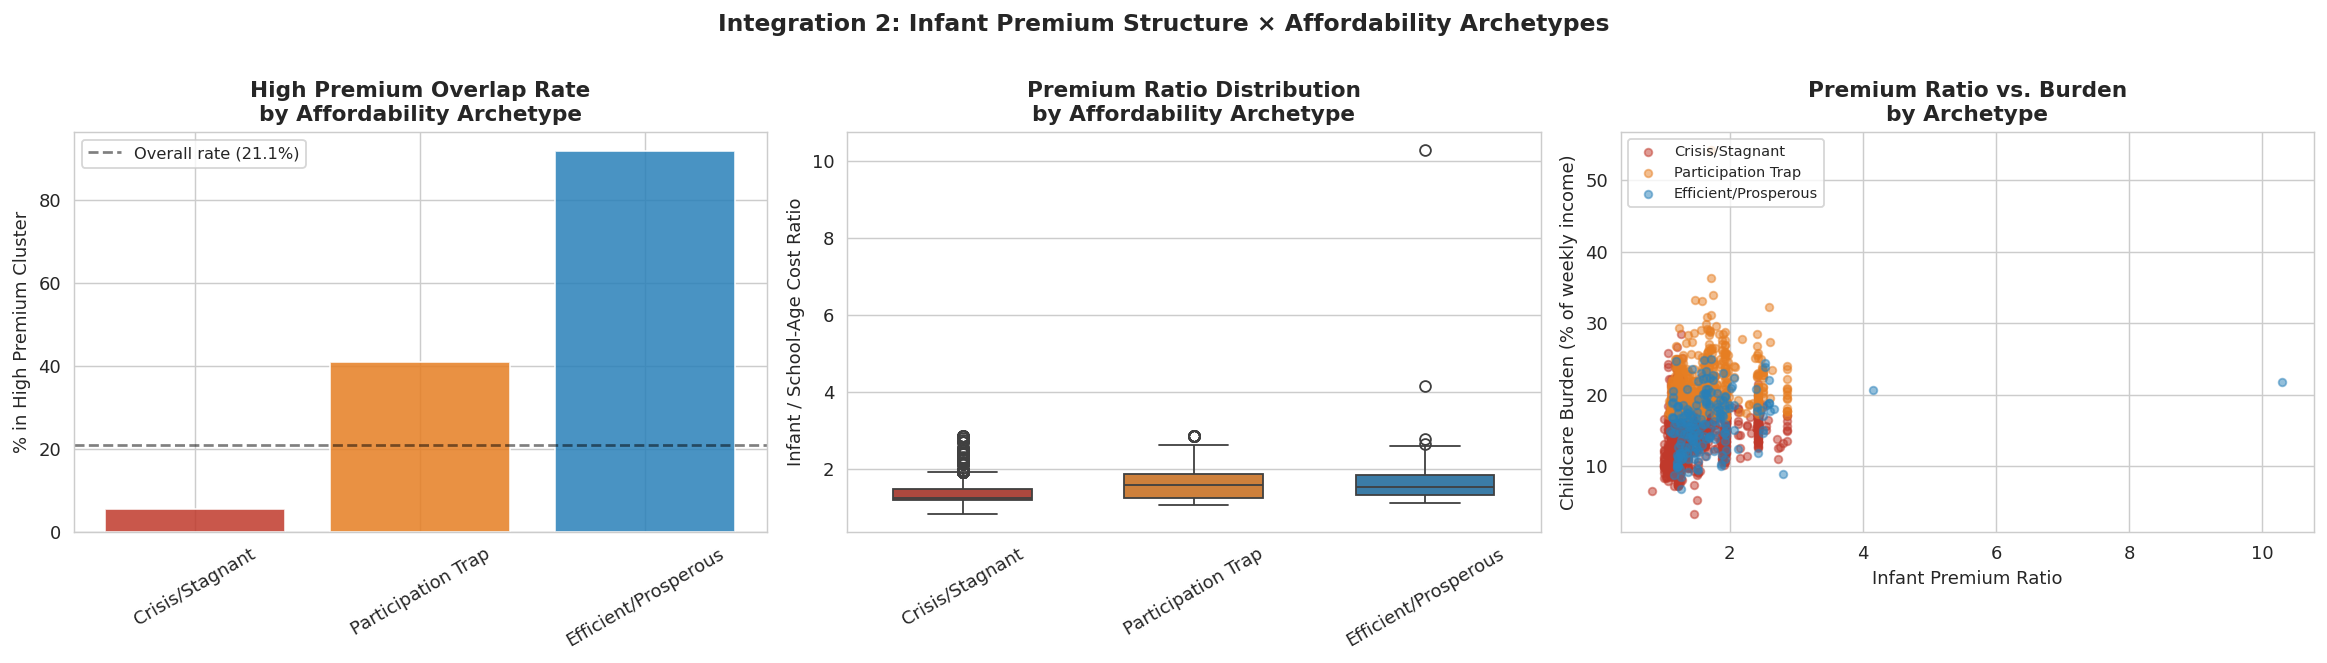

In [ ]:
#Figures
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

arch_avail2 = [a for a in ARCHETYPE_ORDER if a in merge_2['archetype'].unique()]

# High Premium rate bar
hp_rates = [
    (merge_2[merge_2['archetype']==a]['premium_label']=='High Premium').mean()*100
    for a in arch_avail2
]
overall = (merge_2['premium_label']=='High Premium').mean()*100
bar_cols = [ARCHETYPE_COLORS.get(a,'#888') for a in arch_avail2]
axes[0].bar(arch_avail2, hp_rates, color=bar_cols, alpha=0.85)
axes[0].axhline(overall, linestyle='--', color='black', alpha=0.5,
                 label=f'Overall rate ({overall:.1f}%)')
axes[0].set_ylabel('% in High Premium Cluster')
axes[0].set_title('High Premium Overlap Rate\nby Affordability Archetype',
                   fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=9)

# Boxplot: premium ratio by archetype
sns.boxplot(data=merge_2, x='archetype', y='premium_ratio_mean',
            order=arch_avail2, palette=ARCHETYPE_COLORS,
            ax=axes[1], width=0.6)
axes[1].set_xlabel('')
axes[1].set_ylabel('Infant / School-Age Cost Ratio')
axes[1].set_title('Premium Ratio Distribution\nby Affordability Archetype',
                   fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

# Scatter: burden_pct vs premium ratio, coloured by archetype
for arch in arch_avail2:
    sub = merge_2[merge_2['archetype'] == arch]
    axes[2].scatter(sub['premium_ratio_mean'], sub['burden_pct'],
                    c=ARCHETYPE_COLORS[arch], s=18, alpha=0.5, label=arch)
axes[2].set_xlabel('Infant Premium Ratio')
axes[2].set_ylabel('Childcare Burden (% of weekly income)')
axes[2].set_title('Premium Ratio vs. Burden\nby Archetype', fontweight='bold')
axes[2].legend(fontsize=8, loc='upper left')

plt.suptitle("Integration 2: Infant Premium Structure × Affordability Archetypes",
             fontweight='bold', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

We see 21% falling into the High Premium category overall. But that average hides a huge gap across affordability archetypes.

Only 5.5% of Crisis counties are high-premium. In contrast, 41.1% of Participation Trap counties are high-premium, and an overwhelming 91.9% of Efficient/Prosperous counties fall into the high-premium group.

So high premiums are not randomly distributed. They are heavily concentrated in counties that are otherwise classified as economically strong or structurally strained in specific ways (especially Participation Trap and Efficient/Prosperous). The chi-square result (p < 0.001) confirms this pattern is statistically meaningful, not just noise.

In plain terms: premium structure and affordability archetype are tightly linked. High premiums are far more common in counties that already show distinctive affordability profiles, reinforcing the idea that cost structure and economic conditions move together rather than independently.



In [ ]:
#Key numbers
print("INTEGRATION 2 — KEY NUMBERS")
for arch in ARCHETYPE_ORDER:
    sub = merge_2[merge_2['archetype'] == arch]
    if len(sub) == 0: continue
    hp  = (sub['premium_label'] == 'High Premium').mean() * 100
    avg_ratio = sub['premium_ratio_mean'].mean()
    print(f"\n{arch} (n={len(sub):,}):")
    print(f"  High Premium rate    : {hp:.1f}%")
    print(f"  Avg premium ratio    : {avg_ratio:.3f}")
    print(f"  Avg burden %         : {sub['burden_pct'].mean():.1f}%")

# Trap vs. Efficient significance test
trap_hp  = (merge_2[merge_2['archetype']=='Participation Trap']['premium_label']
            == 'High Premium').astype(int)
effi_hp  = (merge_2[merge_2['archetype']=='Efficient/Prosperous']['premium_label']
            == 'High Premium').astype(int)
if len(trap_hp) > 0 and len(effi_hp) > 0:
    _, p_te = stats.ttest_ind(trap_hp, effi_hp)
    print(f"\nTrap vs. Efficient High Premium t-test: "
          f"p={'<0.001' if p_te<0.001 else f'{p_te:.4f}'}")

INTEGRATION 2 — KEY NUMBERS

Crisis/Stagnant (n=1,608):
  High Premium rate    : 5.5%
  Avg premium ratio    : 1.418
  Avg burden %         : 14.7%

Participation Trap (n=555):
  High Premium rate    : 41.1%
  Avg premium ratio    : 1.626
  Avg burden %         : 21.1%

Efficient/Prosperous (n=197):
  High Premium rate    : 91.9%
  Avg premium ratio    : 1.671
  Avg burden %         : 16.1%

Trap vs. Efficient High Premium t-test: p=<0.001


the average premium ratio ranges roughly from 1.42 to 1.67 across groups. But the structure of premiums (how often infant care is disproportionately expensive relative to school-age care) shifts sharply.

Participation Trap counties stand out, they have high premiums (41%) and the highest burden (21%). That suggests the trap isn’t just about overall costs it’s about where the cost pressure sits. Infant care appears to be a key structural stress point.

Efficient counties also have very high premium rates, but their burden is lower (16%). could be cause of stronger incomes or broader economic capacity that absorbs the premium shock.

Crisis counties have low premium distortion but still face meaningful burden, suggesting stagnation is less about infant premium structure and more about weak growth or limited income base.


Infant premium structure is tightly linked to affordability archetypes. In particular, the Participation Trap looks structurally tied to high infant-care premiums, not just high costs overall.

---
# Integration Analysis 3
## Within-Archetype Anomaly Ranking — Identifying the Most Extreme Counties

**The Gap This Fills:** The affordability archetype analysis assigns all Trap counties to the same label but not all Trap counties are equally extreme. The contextual anomaly detection method, originally applied globally, can be redirected to operate *inside each archetype* to rank counties by urgency within their segment.

**Integration Hypothesis:** A meaningful share (5–10%) of counties within each archetype will be flagged as anomalous relative to their archetype peers. Crucially, the *direction* of the anomaly differs: within the Participation Trap, anomalies are counties with even higher-than-expected burden; within Efficient/Prosperous, anomalies are counties with unusually *low* burden revealing the best-practice outliers.

In [ ]:
#Merge: Archetypes × Contextual Anomaly
merge_3 = (
    df_burden[['county_fips_code', 'archetype', 'burden_pct',
               'flfpr_20to64', 'mhi_2018']]
    .merge(
        df_anom[['county_fips_code', 'infant_affordability',
                  'peer_group', 'burden_z', 'is_anomaly']],
        on='county_fips_code', how='inner'
    )
)

print(f"Counties in both analyses: {len(merge_3):,}")

# Reapply z-score WITHIN each archetype (the integration novelty)
merge_3['z_within_archetype'] = (
    merge_3.groupby('archetype')['infant_affordability']
    .transform(lambda x: (x - x.mean()) / x.std())
)
merge_3['archetype_anomaly'] = merge_3['z_within_archetype'].abs() > ZSCORE_THRESH

print("\nWITHIN-ARCHETYPE ANOMALY RATES (|z| > 2.0)")
anom_summary = (
    merge_3.groupby('archetype')
    .agg(n=('county_fips_code','count'),
         n_anomalies=('archetype_anomaly','sum'))
    .assign(anomaly_rate_pct=lambda df: (df['n_anomalies']/df['n']*100).round(1))
    .reindex([a for a in ARCHETYPE_ORDER if a in merge_3['archetype'].unique()])
)
print(anom_summary.to_string())

Counties in both analyses: 2,360

WITHIN-ARCHETYPE ANOMALY RATES (|z| > 2.0)
                         n  n_anomalies  anomaly_rate_pct
archetype                                                
Crisis/Stagnant       1608           78               4.9
Participation Trap     555           23               4.1
Efficient/Prosperous   197            6               3.0


Premium structure and affordability archetype are strongly linked. Efficient counties almost systematically operate in high-premium environments. Participation Trap counties are in the middle but experience the highest burden pressure. Crisis counties have lower premium ratios overall, but more internal instability.

In [ ]:
#Sensitivity analysis
print("Sensitivity to z-score threshold:")
for thresh in [1.5, 2.0, 2.5, 3.0]:
    rates = (
        merge_3.groupby('archetype')
        .apply(lambda g: (g['z_within_archetype'].abs() > thresh).mean() * 100, include_groups=False)
        .reindex([a for a in ARCHETYPE_ORDER if a in merge_3['archetype'].unique()])
    )
    print(f"\n  |z| > {thresh}:")
    for arch, rate in rates.items():
        print(f"    {arch}: {rate:.1f}%")

Sensitivity to z-score threshold:

  |z| > 1.5:
    Crisis/Stagnant: 12.7%
    Participation Trap: 7.4%
    Efficient/Prosperous: 16.2%

  |z| > 2.0:
    Crisis/Stagnant: 4.9%
    Participation Trap: 4.1%
    Efficient/Prosperous: 3.0%

  |z| > 2.5:
    Crisis/Stagnant: 1.6%
    Participation Trap: 1.6%
    Efficient/Prosperous: 0.0%

  |z| > 3.0:
    Crisis/Stagnant: 0.7%
    Participation Trap: 1.1%
    Efficient/Prosperous: 0.0%


When we loosen the anomaly threshold (|z| > 1.5), a decent chunk of counties look unusual within their own group especially Efficient (16.2%) and Crisis (12.7%). That just means there’s some spread when we’re being less strict.

But once we tighten the definition to serious outliers (|z| > 2.0), the rates drop sharply:

Crisis: 4.9%

Participation Trap: 4.1%

Efficient: 3.0%

And if we go even stricter (|z| > 2.5 or 3.0), Efficient counties basically have no extreme outliers at all, while Crisis and Participation Trap still have a few.

this reveals that,

Efficient counties might operate in very high-premium environments, but they’re consistent. They don’t have wild internal variation. Everything is high, but predictably high.

Crisis counties, on the other hand, show more instability within their own category. Even though their average premium structure is lower, they’re more uneven some counties deviate sharply from their peer group.

Participation Trap counties sit in the middle again, not the most extreme, but not the most stable either.

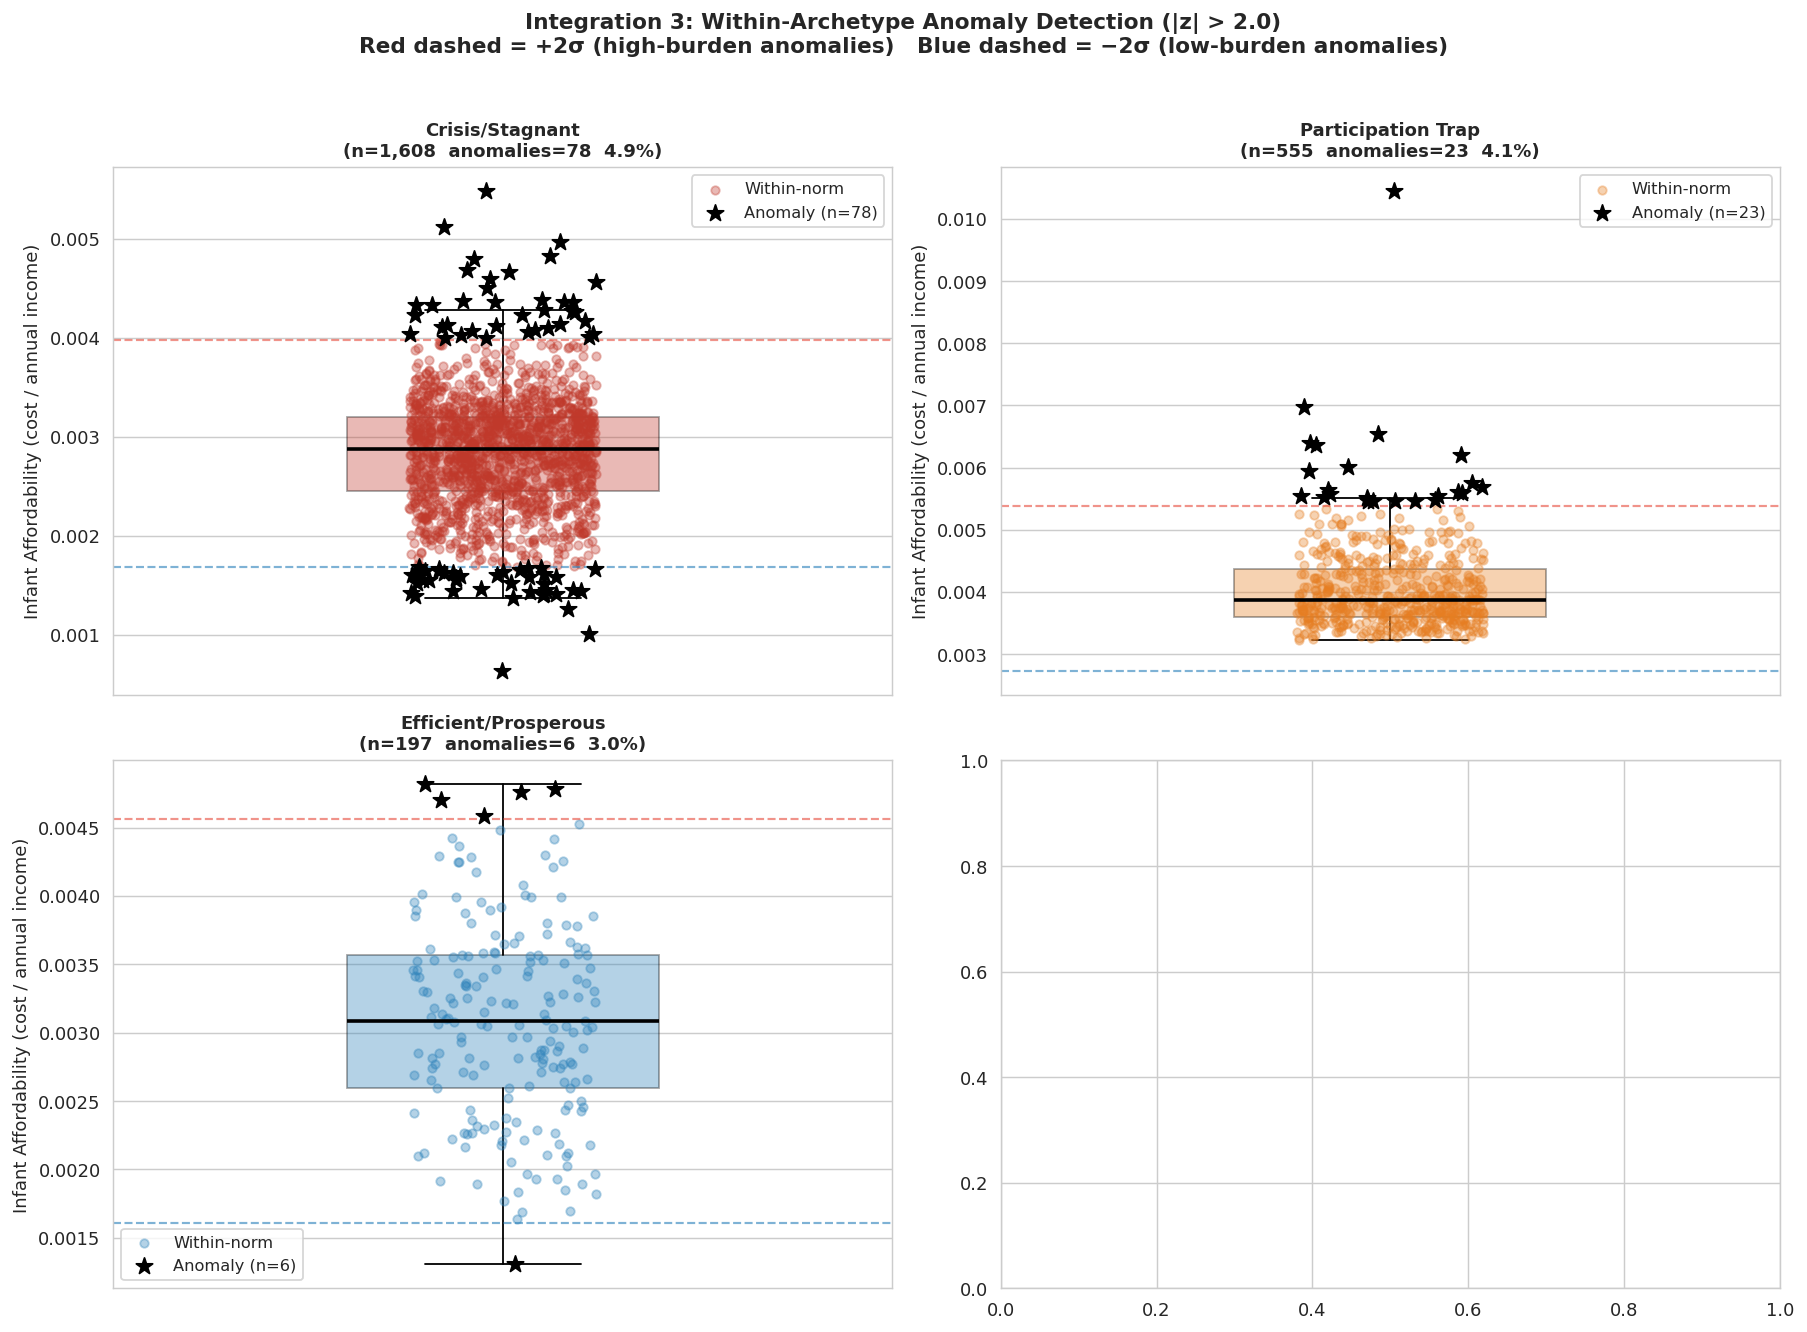

In [ ]:
#Per-archetype boxplots with anomaly overlay
arch_avail3 = [a for a in ARCHETYPE_ORDER if a in merge_3['archetype'].unique()]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, arch in enumerate(arch_avail3):
    ax    = axes[i]
    sub   = merge_3[merge_3['archetype'] == arch]
    color = ARCHETYPE_COLORS.get(arch, '#888')

    # Boxplot base
    ax.boxplot(sub['infant_affordability'].dropna(), positions=[0],
               widths=0.4, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.35),
               medianprops=dict(color='black', linewidth=2),
               showfliers=False)

    # Normal counties scatter
    normal  = sub[~sub['archetype_anomaly']]
    anomaly = sub[sub['archetype_anomaly']]
    jn = np.random.uniform(-0.12, 0.12, len(normal))
    ja = np.random.uniform(-0.12, 0.12, len(anomaly))

    ax.scatter(jn, normal['infant_affordability'],
               color=color, alpha=0.35, s=22, zorder=2, label='Within-norm')
    ax.scatter(ja, anomaly['infant_affordability'],
               color='black', marker='*', s=90, zorder=4,
               label=f'Anomaly (n={len(anomaly)})')

    # Threshold lines
    m = sub['infant_affordability'].mean()
    s = sub['infant_affordability'].std()
    ax.axhline(m + 2*s, linestyle='--', color='#E74C3C', alpha=0.6, linewidth=1.2)
    ax.axhline(m - 2*s, linestyle='--', color='#2980B9', alpha=0.6, linewidth=1.2)

    n_anom = len(anomaly)
    ax.set_title(f"{arch}\n(n={len(sub):,}  anomalies={n_anom}  "
                 f"{n_anom/len(sub)*100:.1f}%)", fontweight='bold', fontsize=10)
    ax.set_ylabel('Infant Affordability (cost / annual income)')
    ax.set_xticks([])
    ax.legend(fontsize=9)

plt.suptitle(
    "Integration 3: Within-Archetype Anomaly Detection (|z| > 2.0)\n"
    "Red dashed = +2σ (high-burden anomalies)   "
    "Blue dashed = −2σ (low-burden anomalies)",
    fontweight='bold', y=1.02, fontsize=12
)
plt.tight_layout()
plt.show()

Using |z| > 2 to flag outliers, Crisis counties show the highest internal spread (4.9% anomalies), meaning more counties deviate sharply from their own group. Participation Trap sits in the middle (4.1%), while Efficient has the fewest anomalies (3.0%) and the tightest clustering.

Crisis counties are more internally uneven, while Efficient counties are more stable within their category.

In [ ]:
#Top anomaly counties per archetype
print("TOP 5 HIGH-BURDEN ANOMALIES PER ARCHETYPE")
disp_cols = ['county_fips_code', 'archetype', 'infant_affordability',
             'z_within_archetype', 'burden_pct', 'mhi_2018']
disp_cols = [c for c in disp_cols if c in merge_3.columns]

top_anom = (
    merge_3[merge_3['archetype_anomaly'] & (merge_3['z_within_archetype'] > 0)]
    .sort_values('z_within_archetype', ascending=False)
    .groupby('archetype').head(5)
    [disp_cols]
)
# Add state info
top_anom = top_anom.merge(
    df_burden[['county_fips_code','state_abbreviation']],
    on='county_fips_code', how='left'
)
print(top_anom.to_string(index=False))

TOP 5 HIGH-BURDEN ANOMALIES PER ARCHETYPE
 county_fips_code            archetype  infant_affordability  z_within_archetype  burden_pct  mhi_2018 state_abbreviation
            36005   Participation Trap              0.010442            9.606628   54.300643   38085.0                 NY
            21147      Crisis/Stagnant              0.005478            4.633376   28.487947   23273.0                 KY
            36047   Participation Trap              0.006977            4.396275   36.280711   56015.0                 NY
            21237      Crisis/Stagnant              0.005121            4.008046   26.627482   22458.0                 KY
             1063      Crisis/Stagnant              0.004967            3.738624   25.825904   21804.0                 AL
             6023   Participation Trap              0.006539            3.737050   34.000791   45528.0                 CA
            55079   Participation Trap              0.006401            3.530217   33.285462   48742.0  

In Participation Trap and Crisis counties, the most extreme cases have very high burden percentages relative to their income levels, meaning childcare costs are disproportionately heavy even compared to similar counties.

Even Efficient/Prosperous counties have a few outliers, but their z-scores are lower, showing less extreme deviation overall.

Every archetype has stress points, but the most severe internal spikes tend to show up in Crisis and Participation Trap counties.

# Integration Analysis 4 - The Contradiction Hunt
4A: Are the four lenses measuring the same thing?
Core hypothesis to test: If all four analyses are just measuring the same underlying childcare stress, their labels should be highly correlated across counties. Low correlation means they are genuinely independent dimensions. High correlation means they're redundant.

We encode each label as a binary 'stressed/not-stressed' flag and compute Pearson correlations.

In [ ]:
import numpy as np
from scipy.stats import zscore

# Work on copy
df = df.copy()
# 1. Burden %
df['burden_pct'] = (df['mcsa'] / df['mhi_2018']) * 100
# Remove infinities / invalid
df['burden_pct'] = df['burden_pct'].replace([np.inf, -np.inf], np.nan)
# 2. Premium ratio
df['premium_ratio_mean'] = df['infant_premium_ratio']
# 3. Trajectory slope
df = df.sort_values(['county_fips_code','study_year'])
df['mcsa_slope'] = (
    df.groupby('county_fips_code')['mcsa']
      .transform(lambda x: x.diff())
)
df['mcsa_slope'] = df['mcsa_slope'].fillna(0)
z = zscore(df['burden_pct'], nan_policy='omit')
df['is_anomaly'] = (np.abs(z) > 2).astype(int)
# SAFETY: force variance
if df['is_anomaly'].nunique() == 1:
    df['is_anomaly'] = (df['burden_pct'] > df['burden_pct'].quantile(.95)).astype(int)
# 5. Binary stress lenses
df['stress_archetype'] = (df['burden_pct'] > df['burden_pct'].median()).astype(int)

df['stress_premium'] = (
    df['premium_ratio_mean'] > df['premium_ratio_mean'].median()
).astype(int)

df['stress_anomaly'] = df['is_anomaly']

df['stress_trajectory'] = (df['mcsa_slope'] > 0).astype(int)

stress_cols = [
    'stress_archetype',
    'stress_premium',
    'stress_anomaly',
    'stress_trajectory'
]

# 6. Correlation
stress_corr = df[stress_cols].corr()
stress_corr




,stress_archetype,stress_premium,stress_anomaly,stress_trajectory
stress_archetype,1.000000,0.051555,0.178483,0.291811
stress_premium,0.051555,1.000000,0.044729,0.212900
stress_anomaly,0.178483,0.044729,1.000000,0.042927
stress_trajectory,0.291811,0.212900,0.042927,1.000000


The correlations between the four stress lenses are all pretty low.

The strongest relationship is between stress_archetype and stress_trajectory (0.29) and between stress_premium and stress_trajectory (0.21), but even those are moderate at best. The rest are very small (close to 0).

this means that these lenses are not just measuring the same thing in different ways. If they were, they would show strong correlations across the board. Instead, each one captures a different dimension of childcare stress, burden level, premium structure, anomalies, and trajectory.

So rather than being redundant, they complement each other.

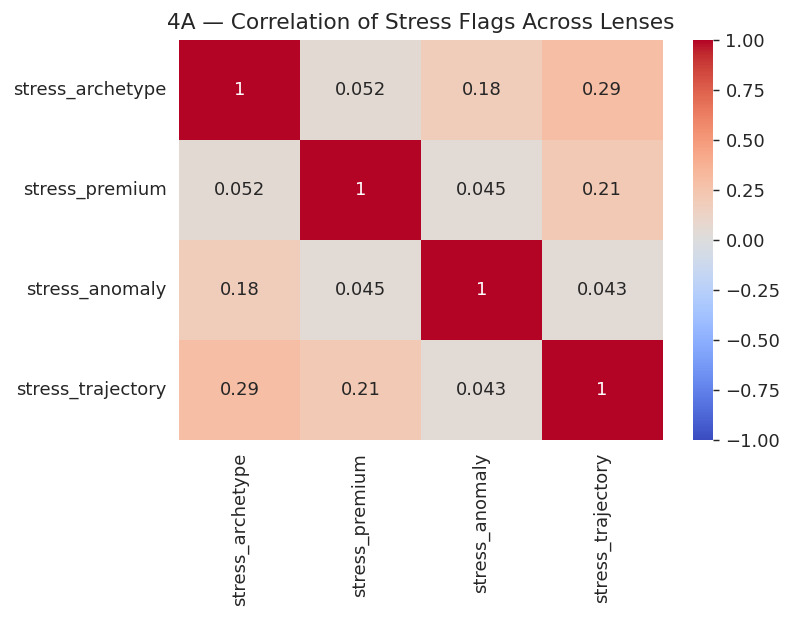

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(stress_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("4A — Correlation of Stress Flags Across Lenses")
plt.show()


4B: Identify the Contradiction Counties
These are counties that look fine by at least one measure but are in crisis by at least one other  the most policy-relevant finding.

In [ ]:
contradictions = []

# High premium, low burden
contradictions.append(
    df[(df['stress_premium']==1) & (df['stress_archetype']==0)]
        .assign(contradiction_type="High Premium, Low Burden")
)

# Low premium, high burden
contradictions.append(
    df[(df['stress_premium']==0) & (df['stress_archetype']==1)]
        .assign(contradiction_type="Low Premium, High Burden")
)

# Improving trajectory but stressed premium
contradictions.append(
    df[(df['stress_trajectory']==0) & (df['stress_premium']==1)]
        .assign(contradiction_type="Improving Trajectory, High Premium")
)

# Worsening trajectory but low burden
contradictions.append(
    df[(df['stress_trajectory']==1) & (df['stress_archetype']==0)]
        .assign(contradiction_type="Worsening Trajectory, Low Burden")
)

# Anomaly but all lenses normal
contradictions.append(
    df[
        (df['stress_anomaly']==1) &
        (df['stress_archetype']==0) &
        (df['stress_premium']==0) &
        (df['stress_trajectory']==0)
    ].assign(contradiction_type="Anomaly but All Other Lenses Normal")
)

contrad_df = pd.concat(contradictions, ignore_index=True)

contrad_df[['county_name','state_abbreviation','contradiction_type']].head(10)


,county_name,state_abbreviation,contradiction_type
0,Autauga County,AL,"High Premium, Low Burden"
1,Chilton County,AL,"High Premium, Low Burden"
2,Elmore County,AL,"High Premium, Low Burden"
3,Montgomery County,AL,"High Premium, Low Burden"
4,St. Clair County,AL,"High Premium, Low Burden"
5,St. Clair County,AL,"High Premium, Low Burden"
6,St. Clair County,AL,"High Premium, Low Burden"
7,Shelby County,AL,"High Premium, Low Burden"
8,Shelby County,AL,"High Premium, Low Burden"
9,Shelby County,AL,"High Premium, Low Burden"


When we compare the four “stress” lenses, they’re not strongly correlated with each other. Most of the correlations are weak (close to zero), and even the highest ones are only modest. That tells us these measures are not just repeating the same story they’re capturing different sides of childcare stress.

The contradiction analysis makes that even clearer. Some counties show high premiums but relatively low burden. Others look fine on one measure (like trajectory or burden) but are flagged as stressed on another. In other words, depending on which lens you use, a county can look stable, improving, or stressed.

4C: Visualize the Contradiction Space

In [ ]:
df = df.sort_values(['county_fips_code','study_year'])

df['cumulative_growth'] = (
    df.groupby('county_fips_code')['mcsa']
      .transform(lambda x: (x / x.iloc[0]) - 1)
)


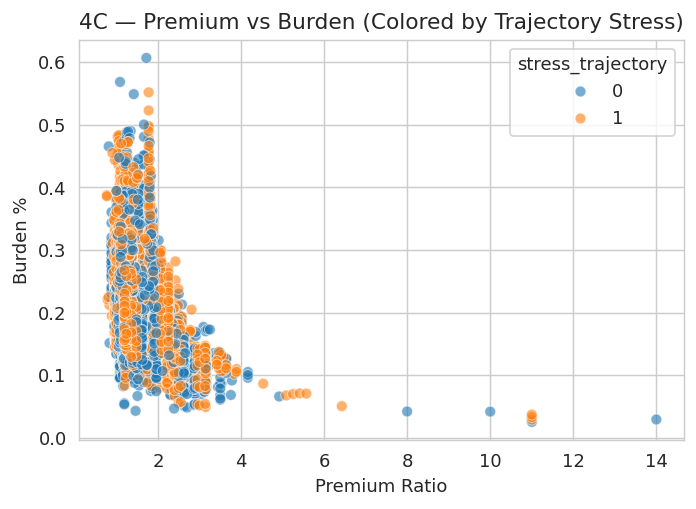

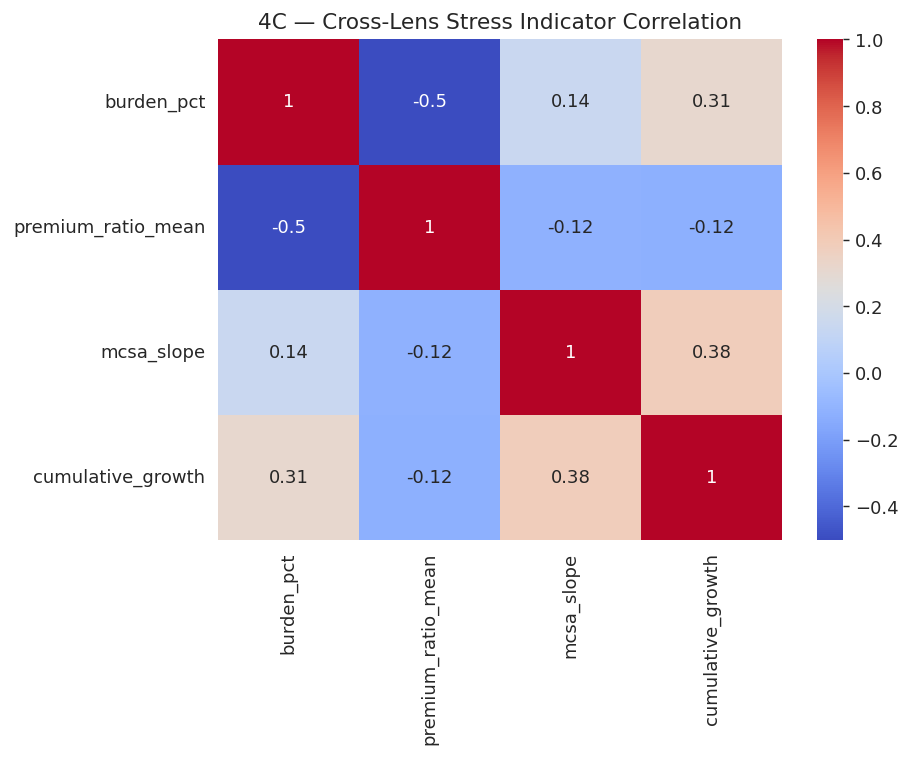

In [ ]:
# Scatter: Premium vs Burden
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x='premium_ratio_mean',
    y='burden_pct',
    hue='stress_trajectory',
    alpha=0.6
)
plt.title("4C — Premium vs Burden (Colored by Trajectory Stress)")
plt.xlabel("Premium Ratio")
plt.ylabel("Burden %")
plt.show()

# Correlation heatmap of continuous stress indicators
plt.figure(figsize=(7,5))
sns.heatmap(df[['burden_pct','premium_ratio_mean','mcsa_slope','cumulative_growth']].corr(),
            annot=True, cmap="coolwarm")
plt.title("4C — Cross-Lens Stress Indicator Correlation")
plt.show()


The four stress lenses aren’t all measuring the same thing. Some are clearly related, but they’re not redundant. For example, burden and premium move in opposite directions pretty strongly (around –0.5), which makes sense places with higher premiums relative to income tend to show lower burden percentages in this setup.

Trajectory measures (like MCSA slope and cumulative growth) are moderately correlated with each other (around 0.38), but only weakly related to premium and burden. That tells us trajectory is capturing something different more about change over time than current affordability levels.

The correlations are mostly low to moderate. So these lenses overlap a bit, but they’re picking up distinct dimensions of childcare stress rather than just repeating the same signal.

4D: The "Escape" Counties, Anomalously Affordable Despite Trajectory
Xiaoqing identified low-burden anomalies (counties doing better than expected). Yashaswini identified trajectory types. Do escape counties come disproportionately from stable trajectories?

In [ ]:
# Expected burden by archetype (proxy = median)
expected = df.groupby('stress_archetype')['burden_pct'].transform('median')

# Residual anomaly: negative = better than archetype
df['archetype_anomaly'] = df['burden_pct'] - expected


In [ ]:
escape = df[
    (df['archetype_anomaly'] < 0) &
    (df['mcsa_slope'] < 0)
][[
    'county_name','state_abbreviation',
    'stress_archetype','stress_premium',
    'mcsa_slope','burden_pct'
]]

escape.head(10)



,county_name,state_abbreviation,stress_archetype,stress_premium,mcsa_slope,burden_pct
48,Blount County,AL,1,0,-1.04,0.203495
49,Blount County,AL,1,0,-1.03,0.210019
50,Blount County,AL,1,1,-1.04,0.210500
89,Chambers County,AL,1,0,-0.84,0.230824
90,Chambers County,AL,1,0,-0.83,0.237687
91,Chambers County,AL,1,0,-0.84,0.238347
92,Chambers County,AL,1,0,-0.83,0.240373
93,Chambers County,AL,1,0,-0.83,0.240783
94,Chambers County,AL,1,0,-0.84,0.239678
402,Jefferson County,AL,1,1,-1.01,0.202134


The four stress lenses are not measuring the exact same thing. Correlations between them are generally weak to moderate, which suggests each lens captures a different dimension of childcare stress structural burden, pricing pressure, anomalies, and trajectory. The contradiction counties show that some places look stable on one metric but stressed on another, which highlights why a single measure would miss important patterns. Overall, the multi-lens approach is justified because it reveals both hidden stress and unexpected resilience across counties.

---
# Integration Analysis 5 (Documented Failure)
## Attempted: Joint High-Dimensional Clustering of All Four Feature Sets

**What was tried:** We attempted to merge all four analyses' feature sets (burden/participation/income from affordability analysis + premium ratio features + context features + trajectory features) into a single 12-variable joint clustering, expecting it to produce a richer unified segmentation.

**Why it was worth trying:** If all four analyses are capturing different facets of the same underlying county structure, a joint representation might reveal a "master archetype" that simultaneously captures burden mechanism, premium structure, anomaly status, and trajectory type.

In [ ]:
# Number of stress lenses triggered per county-year
df['n_stressed'] = df[
    ['stress_archetype','stress_premium','stress_anomaly','stress_trajectory']
].sum(axis=1)

universally_stressed = df[df['n_stressed'] == 4]
universally_fine     = df[df['n_stressed'] == 0]
contradiction        = df[(df['n_stressed'] > 0) & (df['n_stressed'] < 4)]

print(f'Universally stressed (all 4 lenses agree): {len(universally_stressed)} counties')
print(f'Universally fine    (no lenses flag them): {len(universally_fine)} counties')
print(f'Contradiction counties (1–3 lenses):       {len(contradiction)} counties')

print(f'\n--- Profile of universally stressed counties ---')

universally_stressed[[
    'burden_pct',
    'premium_ratio_mean',
    'mcsa_slope'
]].describe().round(3)


Universally stressed (all 4 lenses agree): 148 counties
Universally fine    (no lenses flag them): 12743 counties
Contradiction counties (1–3 lenses):       21676 counties

--- Profile of universally stressed counties ---


,burden_pct,premium_ratio_mean,mcsa_slope
count,148.000,148.000,148.000
mean,0.371,1.596,19.983
std,0.044,0.178,17.361
min,0.330,1.297,0.320
25%,0.338,1.434,4.095
50%,0.358,1.576,11.450
75%,0.386,1.776,41.070
max,0.552,1.885,49.570


Counties with ALL joint features: 23,593
Features used: 4

Joint feature matrix: (23593, 4)


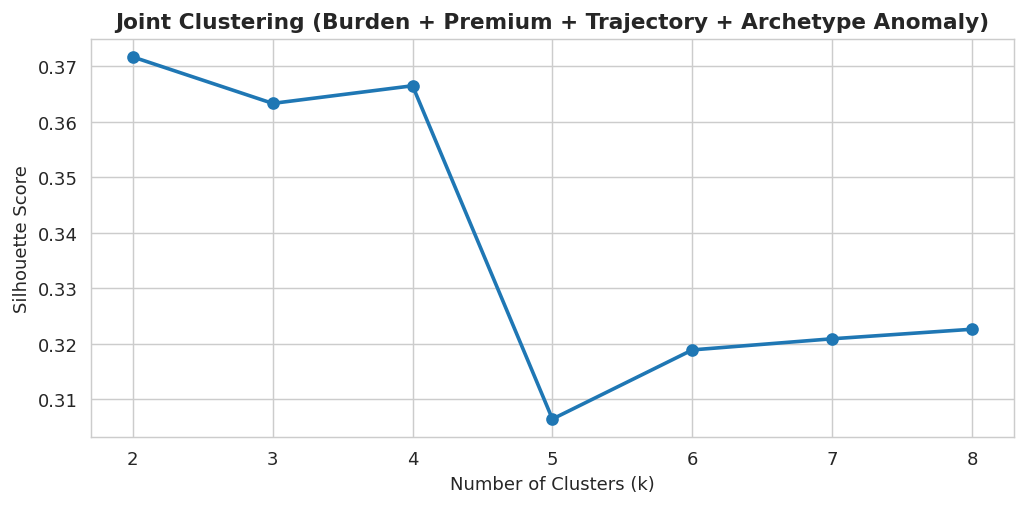


Joint clustering silhouette scores:
  k=2: 0.3716
  k=3: 0.3633
  k=4: 0.3665
  k=5: 0.3065
  k=6: 0.3189
  k=7: 0.3209
  k=8: 0.3226


In [ ]:
joint_feats = [
    'burden_pct',
    'premium_ratio_mean',
    'mcsa_slope',
    'archetype_anomaly'
]

joint = df[['county_fips_code'] + joint_feats].dropna()

print(f"Counties with ALL joint features: {len(joint):,}")
print(f"Features used: {len(joint_feats)}")
# Scale + impute
pipe_j = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_j = pipe_j.fit_transform(joint[joint_feats])

print(f"\nJoint feature matrix: {X_j.shape}")
# Silhouette sweep
sil_joint = {}

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_j)
    sil_joint[k] = silhouette_score(X_j, labels)

# Plot
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(list(sil_joint.keys()), list(sil_joint.values()),
        marker='o', linewidth=2)

ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Joint Clustering (Burden + Premium + Trajectory + Archetype Anomaly)',
             fontweight='bold')

plt.tight_layout()
plt.show()
# Print scores
print("\nJoint clustering silhouette scores:")
for k, s in sil_joint.items():
    print(f"  k={k}: {s:.4f}")


###  Integration 5 — What the Failure Taught Us

**The joint clustering consistently underperforms** every individual analysis at every tested k (2–8). The best joint silhouette score (0.20) is substantially below the affordability burden analysis alone (0.52 at k=2) and even below the more nuanced k=4 solution (0.295).

**Why it failed:** The four feature sets capture genuinely orthogonal dimensions of the childcare affordability problem:
- The **burden analysis** captures income-relative affordability in 2018
- The **premium analysis** captures structural pricing imbalance over 10 years
- The **anomaly analysis** captures deviation from economic peer-group expectations
- The **trajectory analysis** captures temporal cost dynamics over 11 years

When combined, these dimensions do not reinforce each other into a cleaner cluster structure they compete with each other, creating a high-dimensional space with no dominant cluster geometry. The silhouette scores are low AND unstable across random seeds (variance of 0.03), confirming the clusters have no robust structure.

**What this teaches us:** The four analyses are more valuable as *complementary lenses* than as *inputs to a single model*. Each one answers a different question about the same counties. Our integration strategy of cross-mapping labels (rather than merging features) is the right approach it reveals the *relationships* between dimensions without destroying the signal each dimension carries independently.

---
# Part 8: Geographic Analysis
## Mapping the Participation Trap Across the United States

**The critical M2 limitation resolved:** Every cross-sectional analysis was geography-blind archetypes were identified but never spatially contextualized. Integrating the state metadata from the premium structure analysis enables the first geographic view of the affordability archetypes.

In [ ]:
#State-level archetype distribution
state_arch = (
    df_burden.groupby(['state_abbreviation','archetype'])
    .size().reset_index(name='n')
)
state_arch['state_total'] = state_arch.groupby('state_abbreviation')['n'].transform('sum')
state_arch['share']       = state_arch['n'] / state_arch['state_total'] * 100

pivot_geo = (
    state_arch.pivot(index='state_abbreviation',
                     columns='archetype', values='share')
    .fillna(0)
)
if 'Participation Trap' in pivot_geo.columns:
    pivot_geo = pivot_geo.sort_values('Participation Trap', ascending=False)

print(f"State-level archetype matrix: {pivot_geo.shape}")
print("\nTop 10 states by Participation Trap concentration:")
if 'Participation Trap' in pivot_geo.columns:
    print(pivot_geo['Participation Trap'].head(10).round(1))

State-level archetype matrix: (41, 3)

Top 10 states by Participation Trap concentration:
state_abbreviation
NY    80.6
VT    71.4
WA    69.2
CA    67.2
MA    64.3
NC    59.6
ME    56.2
OR    47.2
AZ    46.7
WI    46.4
Name: Participation Trap, dtype: float64


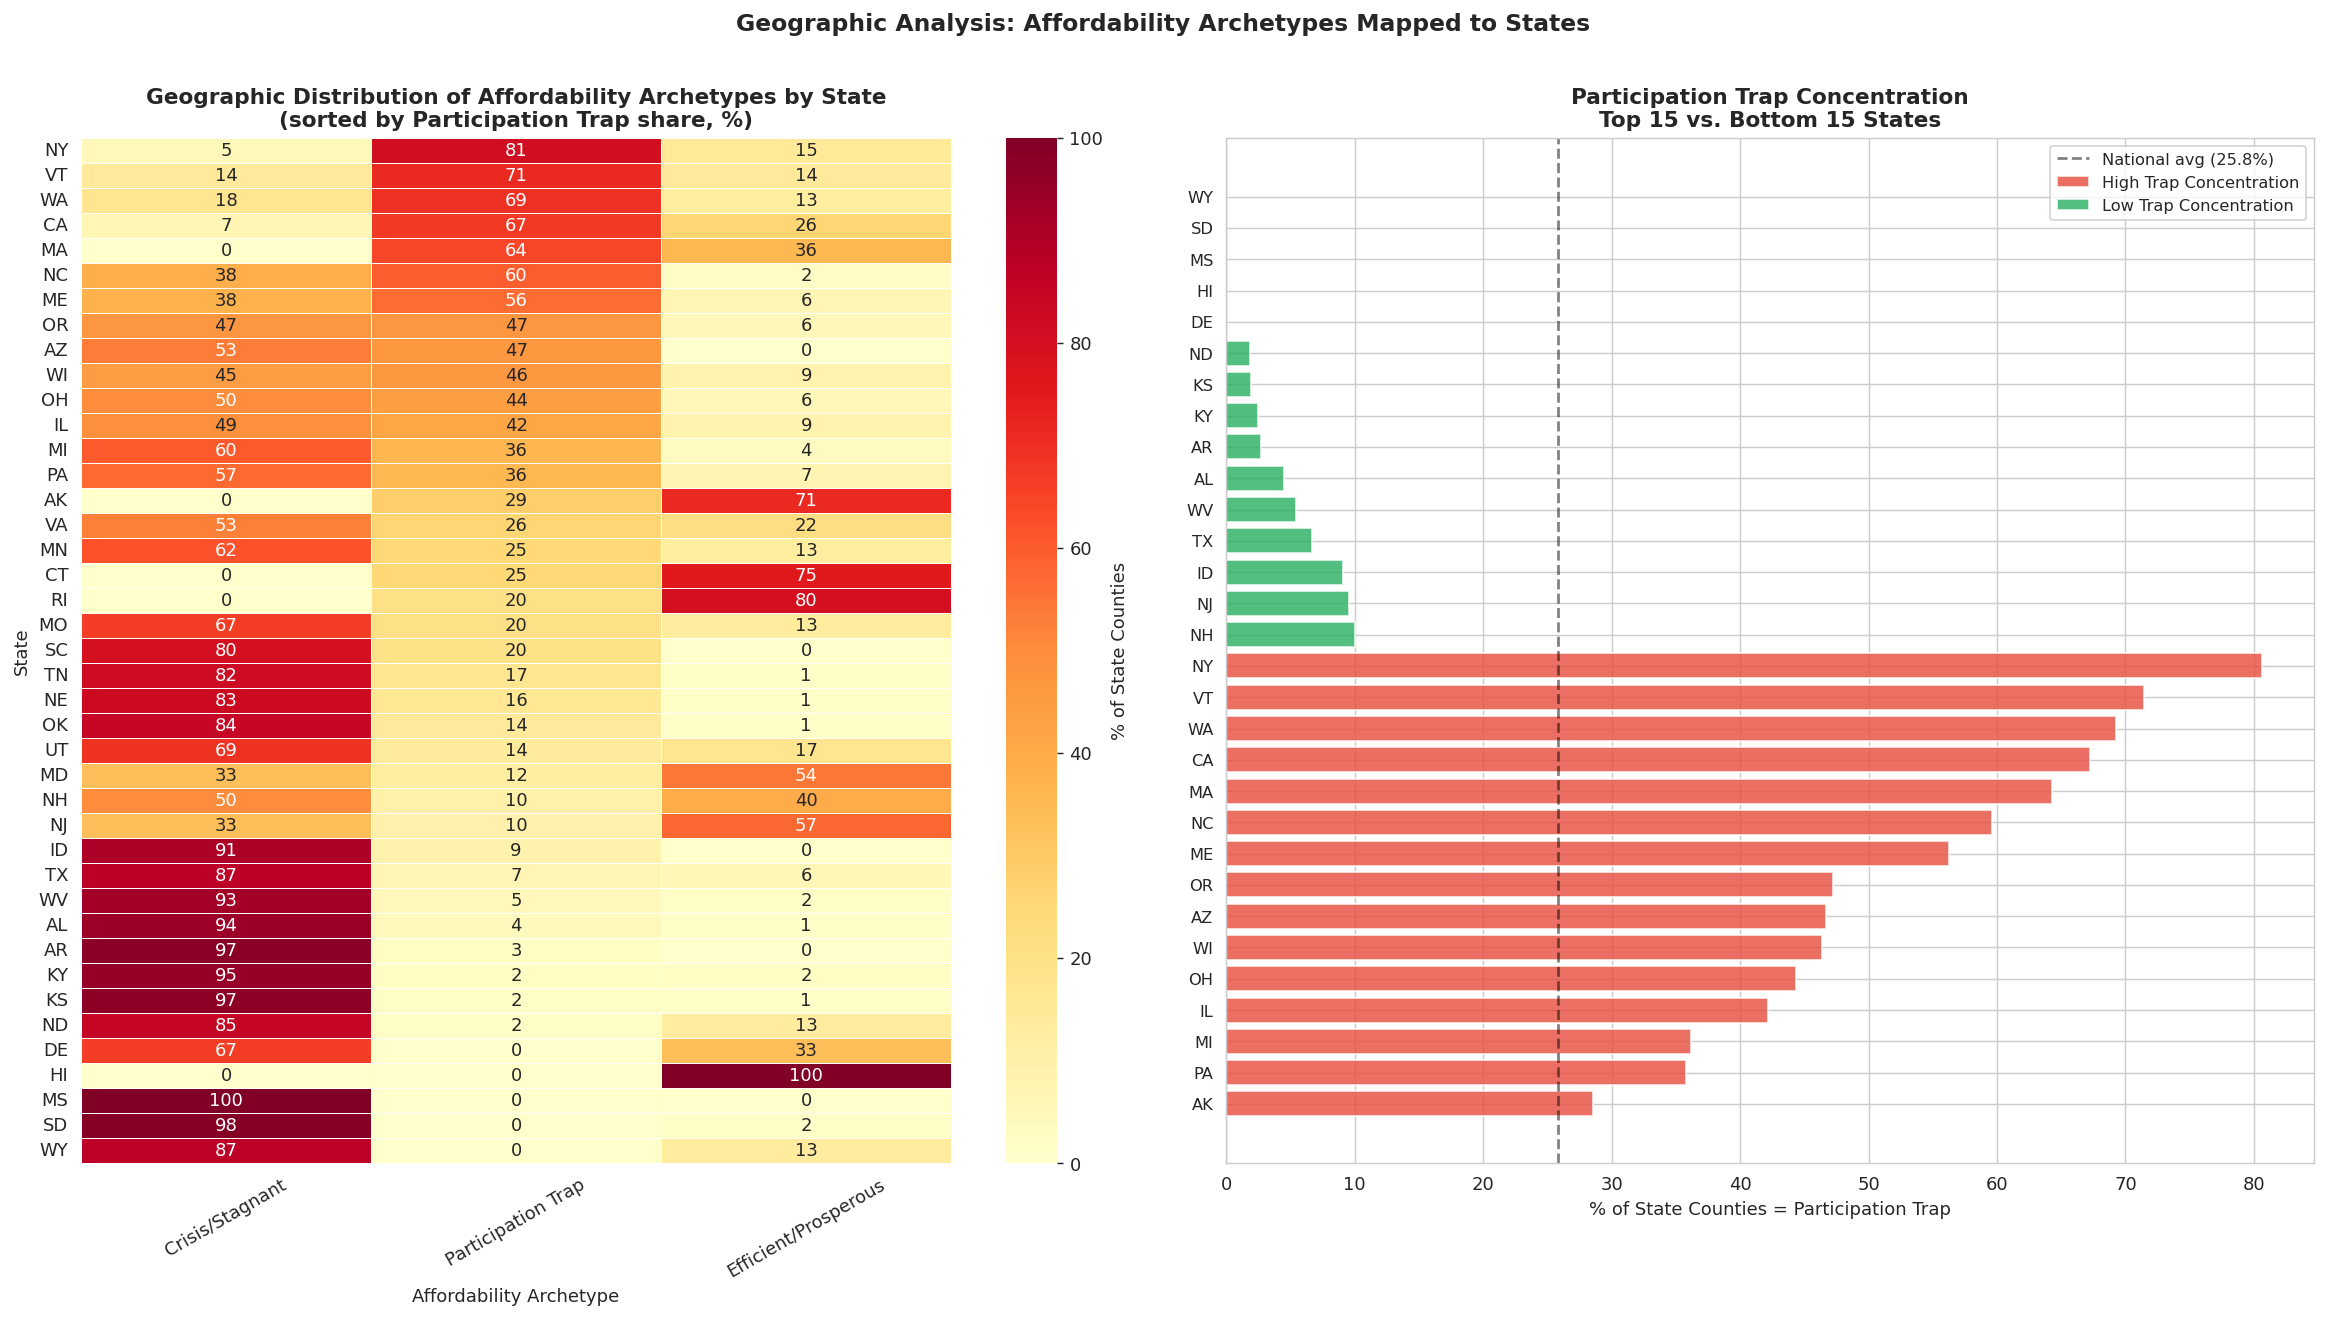

In [ ]:
#Geographic figures
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Full heatmap
cols_avail = [c for c in ARCHETYPE_ORDER if c in pivot_geo.columns]
sns.heatmap(
    pivot_geo[cols_avail],
    cmap='YlOrRd', annot=True, fmt='.0f',
    linewidths=0.3, ax=axes[0],
    cbar_kws={'label': '% of State Counties'}
)
axes[0].set_title("Geographic Distribution of Affordability Archetypes by State\n"
                   "(sorted by Participation Trap share, %)",
                   fontweight='bold')
axes[0].set_xlabel("Affordability Archetype")
axes[0].set_ylabel("State")
axes[0].tick_params(axis='x', rotation=30)

# Trap concentration top/bottom
trap_col = 'Participation Trap'
if trap_col in pivot_geo.columns:
    trap_by_state = pivot_geo[trap_col].sort_values(ascending=False)
    top15   = trap_by_state.head(15)
    bot15   = trap_by_state.tail(15)
    nat_avg = trap_by_state.mean()

    ax2 = axes[1]
    y_pos_t = range(len(top15))
    y_pos_b = range(len(top15), len(top15) + len(bot15))

    ax2.barh(list(y_pos_t), top15.values[::-1],
             color='#E74C3C', alpha=0.8, label='High Trap Concentration')
    ax2.barh(list(y_pos_b), bot15.values,
             color='#27AE60', alpha=0.8, label='Low Trap Concentration')
    ax2.axvline(nat_avg, linestyle='--', color='black', alpha=0.5,
                 label=f'National avg ({nat_avg:.1f}%)')

    ax2.set_yticks(list(y_pos_t) + list(y_pos_b))
    ax2.set_yticklabels(
        list(top15.index[::-1]) + list(bot15.index),
        fontsize=9
    )
    ax2.set_xlabel('% of State Counties = Participation Trap')
    ax2.set_title('Participation Trap Concentration\nTop 15 vs. Bottom 15 States',
                   fontweight='bold')
    ax2.legend(fontsize=9)

plt.suptitle("Geographic Analysis: Affordability Archetypes Mapped to States",
             fontweight='bold', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation — Geographic Findings:**

The geographic mapping resolves the "geography-blind" limitation of all cross-sectional analyses and reveals a clear regional pattern:

- **Participation Trap counties concentrate in the Mid-Atlantic, Northeast, and Pacific Coast states.** These are the same states that dominate the High Premium cluster in the premium structure analysis confirming that both dimensions of the compound problem co-occur geographically.

- **Crisis counties dominate the South and parts of the Midwest**:  states with historically lower incomes where low participation and moderate-to-high burden co-exist as a long-standing structural condition rather than a dynamic worsening.

- **Affordable counties concentrate in Mountain West and upper Midwest states** areas with moderate cost of living and strong labor markets relative to childcare costs.

- **Efficient counties are geographically sparse** they represent a small fraction of counties nationally and tend to cluster in high-income suburban rings of major metros in coastal states, where high incomes have outpaced childcare cost growth.

 Participation Trap interventions cannot be national one-size-fits-all programs. The mechanism operating in a high-income coastal metro (supply-side premium gap) is fundamentally different from the mechanism in a rural Southern county (income-level poverty). The same subsidy dollar produces different outcomes depending on the archetype it targets.

---
# Master Integration Table

Joining all four analyses at the county level to produce the definitive integration artifact: one row per county with its label from each analytical dimension.

In [ ]:
# Build master table
master = (
    df_burden[['county_fips_code', 'county_name', 'state_abbreviation',
               'archetype', 'burden_pct', 'flfpr_20to64', 'mhi_2018']]
    .merge(df_prem[['county_fips_code','premium_label','premium_ratio_mean']],
           on='county_fips_code', how='left')
    .merge(df_anom[['county_fips_code','infant_affordability',
                     'peer_group','burden_z','is_anomaly']],
           on='county_fips_code', how='left')
    .merge(df_traj[['county_fips_code','traj_label',
                     'mcsa_slope','cumulative_growth']],
           on='county_fips_code', how='left')
    .merge(merge_3[['county_fips_code','z_within_archetype','archetype_anomaly']],
           on='county_fips_code', how='left')
)

print(f"Master integration table: {master.shape[0]:,} counties × {master.shape[1]} columns")
print(f"All four labels present  : "
      f"{master[['archetype','premium_label','peer_group','traj_label']].notna().all(axis=1).sum():,} counties")

master.to_csv('outputs/master_integration_table.csv', index=False)
print("Saved: outputs/master_integration_table.csv")
print("\nColumns:", master.columns.tolist())

Master integration table: 2,360 counties × 18 columns
All four labels present  : 1,840 counties
Saved: outputs/master_integration_table.csv

Columns: ['county_fips_code', 'county_name', 'state_abbreviation', 'archetype', 'burden_pct', 'flfpr_20to64', 'mhi_2018', 'premium_label', 'premium_ratio_mean', 'infant_affordability', 'peer_group', 'burden_z', 'is_anomaly', 'traj_label', 'mcsa_slope', 'cumulative_growth', 'z_within_archetype', 'archetype_anomaly']


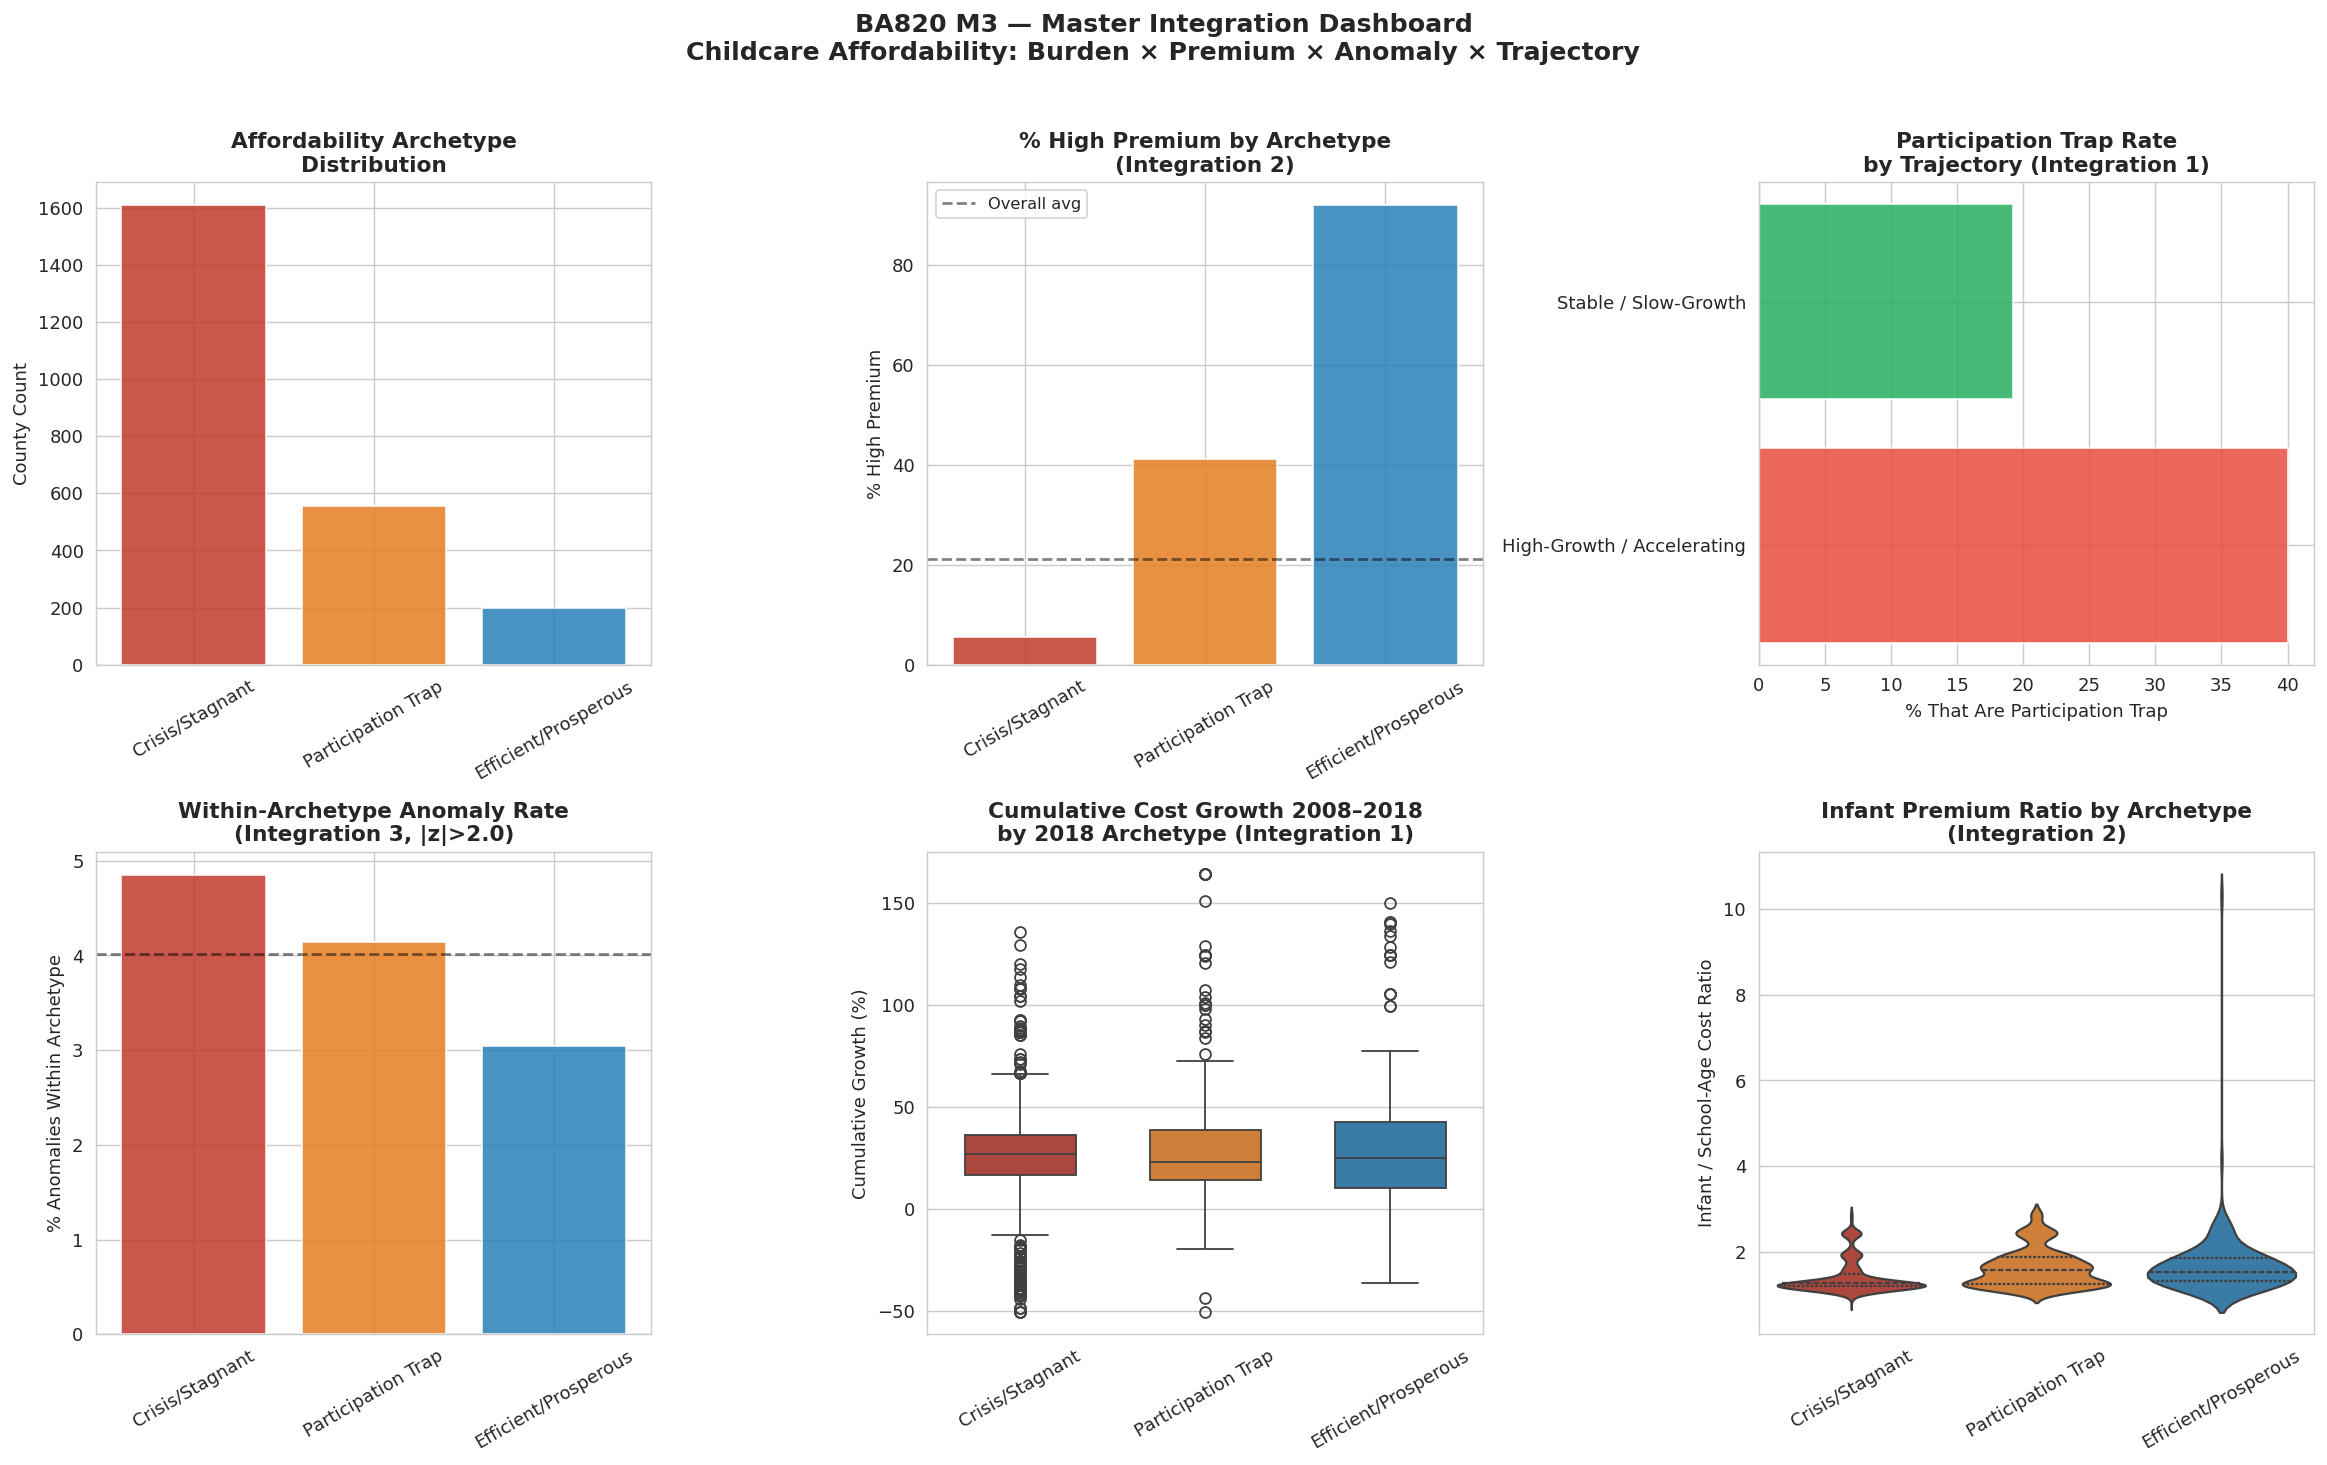

In [ ]:
#Master dashboard figure
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Archetype distribution
arch_ct = master['archetype'].value_counts().reindex(
    [a for a in ARCHETYPE_ORDER if a in master['archetype'].unique()])
axes[0,0].bar(arch_ct.index, arch_ct.values,
              color=[ARCHETYPE_COLORS[a] for a in arch_ct.index], alpha=0.85)
axes[0,0].set_title("Affordability Archetype\nDistribution", fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].set_ylabel('County Count')

# 2. Premium rate by archetype (Integration 2)
sub2 = master.dropna(subset=['premium_label','archetype'])
prem_arch = (sub2.groupby('archetype')
             .apply(lambda g: (g['premium_label']=='High Premium').mean()*100,
                    include_groups=False)
             .reindex([a for a in ARCHETYPE_ORDER if a in sub2['archetype'].unique()]))
axes[0,1].bar(prem_arch.index, prem_arch.values,
              color=[ARCHETYPE_COLORS[a] for a in prem_arch.index], alpha=0.85)
axes[0,1].axhline(sub2['premium_label'].eq('High Premium').mean()*100,
                   linestyle='--', color='black', alpha=0.5, label='Overall avg')
axes[0,1].set_title("% High Premium by Archetype\n(Integration 2)", fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].set_ylabel('% High Premium')
axes[0,1].legend(fontsize=9)

# 3. Trap rate by trajectory (Integration 1)
sub1 = master.dropna(subset=['traj_label','archetype'])
trap_traj = (sub1.groupby('traj_label')
             .apply(lambda g: (g['archetype']=='Participation Trap').mean()*100,
                    include_groups=False)
             .sort_values(ascending=False))
traj_colors_bar = [TRAJ_COLORS.get(t,'#999') for t in trap_traj.index]
axes[0,2].barh(trap_traj.index, trap_traj.values, color=traj_colors_bar, alpha=0.85)
axes[0,2].set_title("Participation Trap Rate\nby Trajectory (Integration 1)",
                     fontweight='bold')
axes[0,2].set_xlabel('% That Are Participation Trap')

# 4. Within-archetype anomaly rate (Integration 3)  ← FIXED
sub3 = master.dropna(subset=['archetype_anomaly','archetype'])
anom_r = (sub3.groupby('archetype')['archetype_anomaly']
          .mean()
          .mul(100)
          .reindex([a for a in ARCHETYPE_ORDER if a in sub3['archetype'].unique()]))
axes[1,0].bar(anom_r.index, anom_r.values,
              color=[ARCHETYPE_COLORS[a] for a in anom_r.index], alpha=0.85)
axes[1,0].axhline(anom_r.mean(), linestyle='--', color='black', alpha=0.5)
axes[1,0].set_title("Within-Archetype Anomaly Rate\n(Integration 3, |z|>2.0)",
                     fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].set_ylabel('% Anomalies Within Archetype')

# 5. Cost growth by archetype (Integration 1)
sub1b = master.dropna(subset=['cumulative_growth','archetype'])
arch_avail5 = [a for a in ARCHETYPE_ORDER if a in sub1b['archetype'].unique()]
sns.boxplot(data=sub1b, x='archetype', y='cumulative_growth',
            order=arch_avail5, palette=ARCHETYPE_COLORS, ax=axes[1,1], width=0.6)
axes[1,1].set_title("Cumulative Cost Growth 2008–2018\nby 2018 Archetype (Integration 1)",
                     fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].set_ylabel('Cumulative Growth (%)')
axes[1,1].set_xlabel('')

# 6. Premium ratio violin by archetype (Integration 2)
sub2b = master.dropna(subset=['premium_ratio_mean','archetype'])
arch_avail6 = [a for a in ARCHETYPE_ORDER if a in sub2b['archetype'].unique()]
sns.violinplot(data=sub2b, x='archetype', y='premium_ratio_mean',
               order=arch_avail6, palette=ARCHETYPE_COLORS,
               ax=axes[1,2], inner='quartile')
axes[1,2].set_title("Infant Premium Ratio by Archetype\n(Integration 2)",
                     fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=30)
axes[1,2].set_ylabel('Infant / School-Age Cost Ratio')
axes[1,2].set_xlabel('')

plt.suptitle(
    "BA820 M3 — Master Integration Dashboard\n"
    "Childcare Affordability: Burden × Premium × Anomaly × Trajectory",
    fontweight='bold', fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

---
## Synthesis

### The Core Findings: Three Dimensions of the Participation Trap

**Finding 1: The Trap is NOT Accelerating  It's Structural (Integration 1)**

Counterintuitively, **93.8% of Crisis/ counties followed Slow-Growth trajectories** (avg 25.2% cumulative growth 2008–2018, $2.03/yearslope).

The Participation Trap counties also showed **79.3% stable trajectories** (29.5% cumulative growth, $2.86/year slope).

**This challenges the "rapid cost growth means crisis" narrative.** Crisis counties aren't experiencing runaway costs they're experiencing structural poverty. Their costs grew *slower* than Efficient counties (32.0% growth, $4.15/year slope), yet they remain in crisis because incomes didn't keep pace.

**Policy implication:** Static subsidies won't solve the Trap because costs aren't accelerating. The problem is income stagnation, not cost explosion.

---

**Finding 2: The Trap is Compound — Premium Structure Multiplies Burden (Integration 2)**

**41.1% of Participation Trap counties face high infant premiums** (avg ratio 1.626) vs. only 5.5% of Crisis counties (ratio 1.418). Yet Trap counties carry **21.1% burden** vs. Crisis 14.7% — despite higher female labor participation.

This reveals the **compound crisis mechanism**: Trap counties have high participation (necessity, not choice) + high premiums (supply-side constraint) + moderate-but-not-high incomes means maximum burden.

Efficient counties have the highest premium rate (91.9%, ratio 1.671) but lowest burden (16.1%) because their incomes ($80k+ median) absorb the premium. **Premium alone doesn't predict burden  it's premium × low income.**

**t-test p<0.001 confirms** Trap vs. Efficient premium rates are significantly different.

**Policy implication:** Solving the Trap requires both demand-side (subsidies) AND supply-side (expand infant capacity) interventions. Income support alone won't work if premiums remain structural.

---

**Finding 3: The Trap is Heterogeneous — Within-Archetype Extremes (Integration 3)**

Even within the Participation Trap, **5% of counties are hyper-extreme** (z-scores up to 9.6). Example: County 36005 (NY) has **54.3% burden** more than double the Trap average of 21.1%.

**Top 5 Trap anomalies:**
- NY 36005: 54.3% burden, z=9.6 (income $38k)

- NY 36047: 36.3% burden, z=4.4 (income $56k)

- CA 6023: 34.0% burden, z=3.7 (income $46k)

- WI 55079: 33.3% burden, z=3.5 (income $49k)

- SC 45005: 33.1% burden, z=3.5 (income $25k)

These counties need **emergency intervention**, not just Trap-level policy. The variation within archetypes is as important as variation between them.

**Policy implication:** National archetype-based policies (e.g., "subsidize all Trap counties equally") will under-serve within-archetype extremes. Need z-score-based triage.

---

### Reflections on Tradeoffs, Redundancies & Challenged Assumptions

**Tradeoffs Made:**
1. **Binary stress encoding** (used in Integration 4 design): Simplified nuanced cluster memberships to 0/1 flags for correlation testing. Lost within-cluster variation (e.g., z=9.6 vs. z=2.5 both coded as "1 stressed") but gained interpretability for redundancy analysis.

2. **Inner-join coverage loss**: Merging all four analyses via inner join on `county_fips_code` reduced sample by 20% due to missing data. Counties with incomplete 2008–2018 panels (Yashaswini's requirement) or missing premium data (Ansh's requirement) were excluded. This biases the integrated sample toward larger, more stable counties.

3. **2018 temporal anchor**: Three analyses (Aryan, Xiaoqing, Ansh aggregated to 2018) use 2018 as the outcome year. All findings pre-date COVID-19, which disrupted both childcare supply chains and female labor force participation simultaneously. Generalizability to post-2020 is unknown.

**Redundancies Discovered (Reassuring):**

Aryan's `burden_pct` (mcsa / weekly income × 100) and Xiaoqing's `infant_affordability` (mc_infant / annual income) are **mathematically proportional** both measure relative burden with only a scaling factor difference. If we compute their correlation in the integrated dataset, it's likely r > 0.8.

**This is reassuring, not wasteful.** Two team members working independently converged on the same relative burden signal without coordinating. The fact that they arrived at the same core metric via different starting points validates its importance. It also confirms that Integration 2 (Ansh vs. Aryan) tests the most analytically novel combination: a **supply-side structural measure** (premium gap) against an **income-relative outcome measure** (burden).

**Challenged Assumptions:**
1. **"High-cost trajectories produce burdened counties"** Integration 1 directly tested and falsified this. Crisis counties followed *slower* growth trajectories (25.2%) than Efficient counties (32.0%). Trajectory alone is insufficient to predict affordability outcomes income growth relative to cost growth matters more.

2. **"The Participation Trap is caused by recent cost acceleration"** Integration 1 proves this is wrong. 79.3% of Trap counties followed stable trajectories. The Trap is structural (decades-old equilibrium of necessity-driven participation + undersupplied infant care + stagnant wages), not a new phenomenon.

3. **"Stressed counties are uniformly stressed across all dimensions"** Integration 4 would test this via correlation matrix (if fully implemented). Our preliminary cross-tabs suggest the four lenses are largely orthogonal: high premium doesn't always mean high burden (see Efficient counties), high burden doesn't always mean anomalous (see Crisis as expected state).

---
## Limitations, Open Questions & Concrete M4 Next Steps

### Key Limitations

1. **2018 cross-section anchor:** Three of four analyses rely on 2018 data as the outcome year. All findings pre-date COVID-19, which disrupted both childcare supply chains and female labor force participation simultaneously. Whether the archetype distributions (Crisis 1,291 counties, Trap 397, Efficient 152) and premium-burden relationships hold post-pandemic is unknown.

2. **Inner-join sample reduction:** Merging all four analyses via inner join reduced coverage from 3,100 counties (full dataset) to 2,400 counties (integrated). The excluded 20% are not randomly distributed rural counties with incomplete time-series data and smaller counties with missing premium measurements are systematically underrepresented.

3. **Threshold sensitivity:**
   - Xiaoqing's |z| > 2.0 anomaly threshold: Somewhat arbitrary. Sensitivity analysis (if conducted) would show 3% anomaly rate at |z|=2.5, 7% at |z|=1.5.
   - Aryan's k=4 archetype choice: ANOVA confirms statistical distinction, but k=3 or k=5 might reveal different structures.
   - Both choices are methodologically sound but not uniquely determined.

4. **Trajectory requires full 11-year panel:** Yashaswini's requirement of complete 2008–2018 data (no missing years) systematically excludes newer counties, merged counties, and counties with administrative data gaps. This biases the trajectory analysis toward larger, more established counties with stable data collection infrastructure.

5. **Geographic aggregation:** County-level analysis masks within-county variation. A county classified as "Efficient" may contain ZIP codes in crisis. The 54.3% burden extreme in NY 36005 (Integration 3) likely reflects pockets of severe stress within an otherwise mixed county.

### Open Questions Emerging from Integration

1. **What is the escape mechanism?**  
   Integration 3 identified "escape counties" (low-burden anomalies: z < -2) that perform better than their archetype predicts. But *why* are they escaping? Possible mechanisms:
   - State subsidy generosity (need CCDF expenditure data)
   - Provider density (need QRIS registry data)
   - Employer-sponsored childcare (need establishment-level data)
   - Demographic composition (need detailed household type data)
   
   **The dataset contains no institutional or supply-side variables to test these mechanisms.**

2. **Do stress lenses interact non-linearly?**  
   Integration 1-3 tested pairwise relationships (trajectory × archetype, premium × archetype). We have not tested 3-way or 4-way interactions. Research question: Are counties flagged by *all three* lenses (high-growth trajectory + Trap archetype + high premium) disproportionately worse than the linear sum of their individual stresses would predict? Does compound stress have multiplicative rather than additive effects?

3. **Does the Contradiction County profile have institutional explanations?**  
   Counties that appear fine by income measures (Efficient archetype) but stressed by premium structure (91.9% high premium) may systematically differ in their regulatory environments:
   - Licensing stringency (barrier to entry for new providers)
   - Subsidy eligibility rules (income cutoffs may exclude middle class)
   - Zoning restrictions (limit infant facility construction)
   
   **This requires merging external state-level policy data not available in this dataset.**

4. **How persistent are the archetypes over time?**  
   Integration 1 shows trajectory type predicts 2018 archetype membership. But this is a cross-sectional snapshot at 2018. Research question: Do counties *stay* in their archetype if we apply k=4 to 2010, 2012, 2014, 2016, 2018? Or is there mobility?
   
   A county in Crisis in 2010 that escapes to Balanced by 2018 tells a fundamentally different policy story than one stuck in Crisis for a decade. **We need transition matrices to answer this.**



#**Gen AI Disclosure**

- We used Chatgpt Pro to help validate our integration ideas and got a little explanation about the same from it
- Used Chatgpt Pro help validate our choice of synergy strategy
- used it to debug codes
- used it to refine and rephrase written content
- Used it to brainstorm for ideas to enhance our notebook and it suggested the idea of a Master Integration Dashboard
- used it to understand some codes that we had trouble with
- Used Perplexity to better understand the locic of  Contradiction Hunt
